<h1 style="text-align: center;">Used Car Price Prediction - Syarah.com</h1>
<h3 style="text-align: center;">Athiyyah Nisrina Husna & Firsa Adam</h3>

---

## **Section 0. Setup**


### **0.1 Import Library**

In [143]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy
import sklearn

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from scipy.stats import randint, uniform, shapiro, spearmanr

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import shap
import joblib

import os


### **0.2 Global Configuration**

In [144]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## **Section 1. Business Understanding**

### **1.1 Context**

Pasar mobil bekas (used car) di Arab Saudi diproyeksikan tumbuh dari USD 6,82 miliar pada tahun 2025 menjadi USD 11,24 miliar pada tahun 2031, dengan CAGR sebesar 8,58% (Mordor Intelligence). Di antara berbagai saluran penjualan, platform digital tercatat sebagai kanal dengan pertumbuhan tercepat dibanding kanal konvensional, didorong oleh siklus transaksi yang lebih cepat dan transparansi harga yang lebih baik. Salah satu pemain utama di segmen ini adalah Syarah.com, platform marketplace mobil bekas online terbesar di Arab Saudi, yang menjadi konteks data pada proyek ini. Namun, di tengah pertumbuhan pesat ini, penentuan harga jual yang wajar dan kompetitif untuk tiap unit mobil bekas tetap menjadi tantangan tersendiri bagi platform seperti Syarah.

### **1.2 Company Profile**

Syarah.com adalah platform marketplace online asal Arab Saudi yang didirikan pada tahun 2015 oleh Fayez Alanazi dan Salah Sharef, berkantor pusat di Riyadh, Arab Saudi. Saat ini menjadi salah satu marketplace jual-beli mobil (baru maupun bekas) terbesar di Arab Saudi berdasarkan traffic, dengan model bisnis yang mencakup penjualan langsung ke konsumen, biaya listing dan transaksi, serta layanan tambahan seperti pembiayaan dan pengantaran ke rumah.

### **1.3 Problem Statements**

Dalam praktiknya, sebagian penjual di platform Syarah memilih untuk tidak mencantumkan harga tetap dan menandai listing mereka sebagai "Negotiable", mengandalkan proses tawar-menawar langsung dengan calon pembeli. Pendekatan ini menciptakan ketidakpastian harga di awal transaksi, karena calon pembeli tidak memiliki acuan harga yang jelas, sementara penjual berisiko menetapkan ekspektasi harga yang terlalu tinggi atau terlalu rendah dibanding kondisi pasar. Ketidakpastian ini berpotensi memperlambat proses negosiasi, menurunkan kepercayaan pembeli terhadap listing tanpa harga, dan pada akhirnya mengurangi efisiensi transaksi di platform.

Tanpa model prediksi harga berbasis machine learning yang mampu menganalisis atribut kendaraan (merek, tipe, tahun produksi, jarak tempuh, kondisi mesin, dll) secara terintegrasi, penjual dan pembeli harus mengandalkan intuisi atau perbandingan manual antar listing untuk menentukan harga awal yang wajar sebagai titik acuan negosiasi.

### **1.4 Goals**

Mengembangkan model machine learning regresi yang mampu memberikan estimasi harga referensi untuk listing mobil bekas, termasuk listing dengan status "Negotiable" yang belum memiliki harga tetap. Estimasi ini dibangun berdasarkan atribut kendaraan seperti merek, tipe, tahun produksi, jarak tempuh, dan kondisi mesin.

Bagi Syarah, model ini diharapkan dapat mempercepat proses negosiasi antara penjual dan pembeli, mengurangi ketergantungan pada intuisi/perbandingan manual dalam menentukan harga awal, serta meningkatkan kepercayaan pengguna terhadap platform lewat transparansi harga yang lebih baik. Pada akhirnya, hal ini berpotensi mempercepat perputaran transaksi dan menjaga potensi pendapatan komisi perusahaan dari setiap listing yang berhasil terjual.

### **1.5 Analytical Approach**

Karena variabel target, *Price*, merupakan nilai numerik kontinu yang merepresentasikan harga wajar sebuah mobil bekas, permasalahan ini termasuk ke dalam kategori regresi. Model machine learning regresi akan dikembangkan menggunakan data historis listing yang sudah memiliki harga tetap (non-Negotiable), mempelajari pola hubungan antara atribut kendaraan dengan harga jualnya. Pola ini kemudian dapat diterapkan untuk memberikan estimasi harga referensi pada listing baru, termasuk listing dengan status Negotiable.

### **1.6 Metric Evaluation (Business Metric, Machine Learning Evaluation Metric)**

Karena permasalahan proyek ini adalah masalah regresi, evaluasi model difokuskan seberapa dekat hasil prediksi harga dengan nilai aktual, **Mean Absolute Error (MAE)** digunakan sebagai metrik utama karena mudah dinterpretasi secara bisnis, yaitu menunjukkan rata-rata selisih harga antara estimasi model dan harga pasar sebenarnya. **Root Mean Squared Error (RMSE)** digunakan sebagai metrik pendukung untuk memberi penalti lebih besar pada kesalahan prediksi yang ekstrem, mengingat distribusi Price yang right-skewed dengan sejumlah mobil bernilai jauh di atas rata-rata pasar. R² (koefisien determinasi) turut dilaporkan sebagai metrik pendukung untuk melihat proporsi variansi harga yang mampu dijelaskan model secara keseluruhan.

Dalam konteks bisnis, kesalahan **overestimation** (model memprediksi harga lebih tinggi dari harga wajar) dan **underestimation** (harga diprediksi lebih rendah dari harga wajar) sama-sama merugikan meski dengan cara berbeda: harga yang terlalu tinggi memperlambat perputaran unit dan menurunkan daya saing listing di mata pembeli, sementara harga yang terlalu rendah merugikan penjual dan menurunkan potensi pendapatan komisi transaksi bagi platform.

### **1.7 Success Criteria**

**Machine Learning Performance:** Model mencapai nilai MAE yang lebih rendah dibandingkan model dasar (baseline) khususnya model Linear Regression yang merepresentasikan pendekatan penentuan harga paling sederhana, serta mampu menjelaskan minimal 80% variansi harga (R² ≥ 0,80), tanpa indikasi overfitting signifikan antara data training dan testing.

**Business Metrics:** Model diharapkan menghasilkan estimasi harga dengan deviasi rata-rata (MAE) yang jauh lebih kecil dibandingkan pendekatan penentuan harga manual/subjektif, sehingga dapat diandalkan sebagai alat bantu penentuan harga otomatis di platform. Hal ini diharapkan mempercepat proses transaksi dan menjaga transparansi harga bagi penjual maupun pembeli, tanpa bias sistematis ke arah *overestimate* atau *underestimate* yang dapat merugikan salah satu pihak.

## **Section 2. Data Understanding**

(Dataset source: https://www.kaggle.com/datasets/turkibintalib/saudi-arabia-used-cars-dataset)

Note: Setiap baris merepresentasikan satu listing/iklan mobil bekas yang dijual di platform Syarah.com pada tahun 2021.

### **2.1 General Information**

In [145]:
df = pd.read_csv("../data/raw/UsedCarsSA_Unclean_EN.csv")
df.head()

,Link,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable
0,https://syarah.com/%D9%83%D8%B1%D8%A7%D9%8A%D8...,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,Used,103000,Riyadh,114000,False
1,https://syarah.com/%D9%86%D9%8A%D8%B3%D8%A7%D9...,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,Used,5448,Riyadh,Negotiable,True
2,https://syarah.com/online/%D9%86%D9%8A%D8%B3%D...,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,Used,72418,Riyadh,27500,False
3,https://syarah.com/online/%D9%87%D9%88%D9%86%D...,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,Used,114154,Riyadh,43000,False
4,https://syarah.com/online/%D9%87%D9%88%D9%86%D...,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,Used,41912,Riyadh,59500,False


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8248 entries, 0 to 8247
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Link         8248 non-null   object 
 1   Make         8248 non-null   object 
 2   Type         8248 non-null   object 
 3   Year         8248 non-null   int64  
 4   Origin       8153 non-null   object 
 5   Color        8248 non-null   object 
 6   Options      8139 non-null   object 
 7   Engine_Size  5982 non-null   float64
 8   Fuel_Type    8248 non-null   object 
 9   Gear_Type    8174 non-null   object 
 10  Condition    8248 non-null   object 
 11  Mileage      8248 non-null   int64  
 12  Region       8248 non-null   object 
 13  Price        8248 non-null   object 
 14  Negotiable   8248 non-null   bool   
dtypes: bool(1), float64(1), int64(2), object(11)
memory usage: 910.3+ KB


In [147]:
df.shape

(8248, 15)

Dataset ini berisi informasi mobil bekas yang dijual di Arab Saudi (versi mentah/unclean), terdiri dari **8.248 baris** dan **15 kolom**. Berikut deskripsi masing-masing fitur:

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| **Link** | String | URL halaman iklan mobil di situs syarah.com. Sebagian nama mobil dalam URL masih berbahasa Arab (belum diterjemahkan). |
| **Make** | String | Merek/pabrikan mobil (contoh: Toyota, Nissan, Mercedes).|
| **Type** | String | Model/tipe spesifik dari merek tersebut (contoh: Camry, Patrol, C-Class).|
| **Year** | Integer | Tahun produksi/model mobil. |
| **Origin** | String | Asal mobil: `Saudi`, `Gulf Arabic` (negara Teluk lain), `Other` (luar Teluk).|
| **Color** | String | Warna eksterior mobil (15 kategori, contoh: Black, White, Silver).|
| **Options** | String | Level kelengkapan fitur/trim kendaraan, bersifat **ordinal**: `Standard` < `Semi Full` < `Full`. Terdapat nilai kosong (109 baris). |
| **Engine_Size** | Float | Kapasitas mesin dalam liter (L). Semakin besar nilainya, umumnya tenaga mesin semakin besar namun konsumsi bahan bakar juga meningkat.|
| **Fuel_Type** | String | Jenis bahan bakar: `Gas` (bensin), `Diesel`, atau `Hybrid` (kombinasi mesin bensin + motor listrik, tidak memerlukan pengisian daya eksternal). |
| **Gear_Type** | String | Jenis transmisi: `Automatic` atau `Manual`. |
| **Condition** | String | Kondisi mobil. Hanya berisi **satu nilai unik** (`Used`) di seluruh baris, sehingga tidak memberikan informasi tambahan untuk analisis. |
| **Mileage** | Integer | Jarak tempuh kendaraan dalam **kilometer (km)**.|
| **Region** | String | Wilayah/kota penjualan mobil di Arab Saudi (27 wilayah, contoh: Riyadh, Jeddah, Dammam). |
| **Price** | String | Harga jual mobil dalam Riyal Saudi (SAR). Bertipe **String** (bukan Integer) karena bercampur dengan nilai teks `"Negotiable"` untuk mobil yang harganya bisa dinego. |
| **Negotiable** | Boolean | Menunjukkan apakah harga mobil dapat dinegosiasikan (`True`) atau bersifat tetap/fixed (`False`). Konsisten 100% dengan nilai `"Negotiable"` di kolom Price. |

### **2.3 Statistics Summary**

In [148]:
df.describe(include='all')

,Link,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable
count,8248,8248,8248,8248.000000,8153,8248,8139,5982.000000,8248,8174,8248,8.248000e+03,8248,8248,8248
unique,8228,65,435,NaN,3,15,3,NaN,3,2,1,NaN,27,549,2
top,https://syarah.com/%D8%AA%D9%88%D9%8A%D9%88%D8...,Toyota,Land Cruiser,NaN,Saudi,White,Full,NaN,Gas,Automatic,Used,NaN,Riyadh,Negotiable,False
freq,2,2074,374,NaN,6084,3574,3235,NaN,8051,7069,8248,NaN,3312,2596,5652
mean,NaN,NaN,NaN,2014.014064,NaN,NaN,NaN,3.175794,NaN,NaN,NaN,1.494128e+05,NaN,NaN,NaN
std,NaN,NaN,NaN,5.935349,NaN,NaN,NaN,1.567480,NaN,NaN,NaN,3.455258e+05,NaN,NaN,NaN
min,NaN,NaN,NaN,1936.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,1.000000e+02,NaN,NaN,NaN
25%,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,3.700000e+04,NaN,NaN,NaN
50%,NaN,NaN,NaN,2016.000000,NaN,NaN,NaN,2.700000,NaN,NaN,NaN,1.016575e+05,NaN,NaN,NaN
75%,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,1.955520e+05,NaN,NaN,NaN


## **Section 3. Data Cleaning**

>   *Tujuan:* Membersihkan data dari kolom tak relevan, nilai hilang, duplikat, dan inkonsistensi, **dengan urutan yang sudah diperbaiki supaya tidak ada data leakage** - statistik apa pun (modus imputasi, threshold outlier) hanya dihitung dari data training.

### **3.1 Remove Unrelevant Columns**

In [149]:
df.drop(["Link", "Condition"], axis=1, inplace=True)
df.head()

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,Negotiable,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False


### **3.2 Duplicated Values**

Dedup dilakukan di awal karena bersifat deterministik (mencocokkan baris identik) - tidak melibatkan statistik apa pun dari data, sehingga aman dilakukan sebelum split.

In [150]:
print('Jumlah baris duplikat:', df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10)

Jumlah baris duplikat: 69


,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
5019,BMW,X,2015,Saudi,White,Full,2.0,Gas,Automatic,92000,Jeddah,72000,False
5020,BMW,X,2015,Saudi,White,Full,2.0,Gas,Automatic,92000,Jeddah,72000,False
6431,Cadillac,CT4,2020,Saudi,Grey,Semi Full,NaN,Gas,Automatic,5800,Jeddah,155000,False
6432,Cadillac,CT4,2020,Saudi,Grey,Semi Full,NaN,Gas,Automatic,5800,Jeddah,155000,False
3595,Chevrolet,Blazer,2005,Other,Blue,Full,2.0,Gas,Automatic,213000,Abha,13500,False
3596,Chevrolet,Blazer,2005,Other,Blue,Full,2.0,Gas,Automatic,213000,Abha,13500,False
2085,Chevrolet,Camaro,2017,Other,Silver,Full,3.6,Gas,Automatic,99000,Dammam,109000,False
2604,Chevrolet,Camaro,2017,Other,Silver,Full,3.6,Gas,Automatic,99000,Dammam,109000,False
685,Chevrolet,Caprice,2013,Saudi,Silver,Standard,6.2,Gas,Automatic,55769,Riyadh,90000,False
690,Chevrolet,Caprice,2013,Saudi,Silver,Standard,6.2,Gas,Automatic,55769,Riyadh,90000,False


In [151]:
df.drop_duplicates(inplace=True)
print('Shape setelah drop_duplicates:', df.shape)

Shape setelah drop_duplicates: (8179, 13)


### **3.3 Data Consistency Check**

Perbaikan di bagian ini semuanya berupa *mapping* deterministik (memperbaiki typo, mengoreksi tipe data) - bukan statistik yang dihitung dari distribusi data - sehingga aman dilakukan sebelum split.

#### **3.3.1 Column Price**

In [152]:
print('Price == "Negotiable":', (df['Price'] == 'Negotiable').sum())
print('Negotiable == True   :', (df['Negotiable'] == True).sum())

Price == "Negotiable": 2585
Negotiable == True   : 2585


In [153]:
df['Price'] = df['Price'].replace('Negotiable', 0).astype(int)
df["Price"].describe()

count    8.179000e+03
mean     5.366112e+04
std      7.288567e+04
min      0.000000e+00
25%      0.000000e+00
50%      3.650000e+04
75%      7.300000e+04
max      1.150000e+06
Name: Price, dtype: float64

#### **3.3.2 Column Type**

In [154]:
suspicious_types = [
    'Furniture', 'Ciocca', 'Behbehani', 'POS24',
    'Gamble', 'Montero2', 'Copper', 'Koranado'
]
anomali_type = df[df['Type'].isin(suspicious_types)]
print(f"Jumlah baris dengan Type mencurigakan: {len(anomali_type)}")
anomali_type[['Make', 'Type', 'Year', 'Price']]

Jumlah baris dengan Type mencurigakan: 191


,Make,Type,Year,Price
17,MINI,Copper,2016,83000
24,Toyota,Furniture,2021,145000
108,Toyota,Furniture,2019,105000
129,Toyota,Furniture,2019,120000
146,Toyota,Furniture,2017,60000
...,...,...,...,...
7952,Toyota,Furniture,2009,0
8115,Toyota,Furniture,2013,55000
8223,Toyota,Furniture,2012,41000
8235,Toyota,Furniture,2020,0


In [155]:
# Drop baris dengan Type 'Behbehani' (ini nama dealer)
df = df[df['Type'] != 'Behbehani']

# Mapping tervalidasi lewat halaman kategori resmi syarah.com
type_mapping = {
    'Furniture': 'Fortuner',       # Toyota Fortuner
    'Ciocca': 'Sequoia',           # Toyota Sequoia
    'POS24': 'Short Bonnet',       # Mercedes truk klasik "Short Bonnet" (1959-1995)
    'Gamble': 'Ghibli',            # Maserati Ghibli
    'Montero2': 'Mountaineer',     # Mercury Mountaineer
    'Copper': 'Cooper',            # MINI Cooper
    'Koranado': 'Korando',         # SsangYong Korando
}

df['Type'] = df['Type'].replace(type_mapping)

#### **3.3.3 Column Make**

In [156]:
df[df['Make'] == 'Other']

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
2849,Other,Other,2012,Other,Blue,Full,2.4,Gas,Automatic,150,Jazan,0,True
3004,Other,Other,2009,Saudi,Black,Full,NaN,Gas,Automatic,218000,Riyadh,0,True
3078,Other,Other,2019,Other,White,Full,8.0,Diesel,Manual,24643,Qassim,330000,False
4800,Other,Other,2009,Other,Orange,Standard,NaN,Diesel,Manual,1300,Al-Medina,26000,False
5115,Other,Other,2007,Saudi,Red,Standard,3.5,Gas,Manual,125,Qassim,7000,False
5130,Other,Other,1992,Saudi,White,Semi Full,2.2,Gas,Manual,120000,Jeddah,0,True
5437,Other,Other,2011,Other,White,Standard,NaN,Diesel,Manual,100000,Jazan,0,True
5530,Other,Other,2019,Saudi,Brown,Full,1.0,Gas,Manual,4000,Jeddah,39000,False
5588,Other,Other,2006,Saudi,Oily,Standard,6.5,Diesel,Manual,81250,Riyadh,0,True
5715,Other,Other,2021,Other,Yellow,Semi Full,1.2,Gas,Manual,3000,Jeddah,5500,False


In [157]:
df = df[df['Make'] != 'Other']

In [158]:
df[df["Make"]=="Classic"]

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
2697,Classic,Cadillac,1995,Saudi,Red,Full,8.0,Gas,Automatic,119,Riyadh,25000,False
2843,Classic,Jaguar,1936,Other,Bronze,Full,NaN,Gas,Automatic,4750,Tabouk,0,True
5506,Classic,Mini Cooper,1972,Other,Another Color,Full,1.3,Gas,Manual,1000,Dammam,42000,False


In [159]:
# Drop Classic
df = df[df['Make'] != 'Classic']

#### **3.3.4 Column Color**

In [160]:
df['Color'] = df['Color'].replace({'Oily': 'Olive'})
df['Color'].value_counts()

Color
White            3537
Black             951
Silver            904
Grey              724
Another Color     543
Brown             327
Red               280
Golden            228
Blue              228
Navy              164
Bronze            162
Olive              51
Green              39
Yellow             13
Orange              9
Name: count, dtype: int64

#### **3.3.5 Column Engine_Size**

In [161]:
print('Engine_Size dtype sebelum:', df['Engine_Size'].dtype)
df['Engine_Size'] = df['Engine_Size'].astype(float)
print('Engine_Size dtype sesudah:', df['Engine_Size'].dtype)

Engine_Size dtype sebelum: float64
Engine_Size dtype sesudah: float64


### **3.4 Train-Test Split**

> Di versi awal, imputasi missing value (modus per Make+Type) dan threshold outlier (IQR mileage, median price per age_group) dihitung dari **seluruh dataset** (gabungan calon train + calon test) sebelum split dilakukan. Akibatnya, baris-baris yang akan masuk ke test set ikut memengaruhi nilai imputasi dan keputusan baris mana yang dibuang dari train - test set jadi tidak benar-benar "belum pernah dilihat".
>
> Di sini, split dilakukan **sekarang** - setelah pembersihan dasar yang deterministik (Section 3.1-3.3), tapi **sebelum** semua langkah yang melibatkan statistik dari data (Section 3.5 dan 3.6). Statistik-statistik itu akan di-*fit* hanya dari `df_train`, lalu diterapkan ke `df_test`.

In [162]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
df_train = df_train.copy()
df_test = df_test.copy()

print(f'df_train: {df_train.shape}')
print(f'df_test : {df_test.shape}')

df_train: (6528, 13)
df_test : (1632, 13)


### **3.5 Missing Values**

Modus per kombinasi (Make, Type) di-*fit* hanya dari `df_train`, lalu dipetakan ke `df_train` maupun `df_test`. Baris yang kombinasi (Make, Type)-nya tidak punya referensi modus di train (karena hanya muncul di test) akan tetap NaN dan dibuang lewat `dropna()` - sama seperti perlakuan pada baris tanpa referensi sama sekali di notebook asli.

In [163]:
def most_frequent(series):
    vc = series.value_counts()
    return vc.index[0] if len(vc) > 0 else np.nan 

def fit_group_mode_maps(train_df, cols, group_cols):
    """Hitung modus per grup HANYA dari train."""
    return {col: train_df.groupby(group_cols)[col].agg(most_frequent) for col in cols}

def apply_group_mode_impute(subset_df, cols, group_cols, mode_maps):
    subset_df = subset_df.copy()
    for col in cols:
        lookup = subset_df.set_index(group_cols).index.map(mode_maps[col])
        fill_values = pd.Series(lookup, index=subset_df.index)
        subset_df[col] = subset_df[col].fillna(fill_values)
    return subset_df

impute_cols = ['Engine_Size', 'Gear_Type', 'Options']
group_cols = ['Make', 'Type']

# Fit HANYA dari train
mode_maps = fit_group_mode_maps(df_train, impute_cols, group_cols)

# Terapkan ke train & test
df_train = apply_group_mode_impute(df_train, impute_cols, group_cols, mode_maps)
df_test = apply_group_mode_impute(df_test, impute_cols, group_cols, mode_maps)

# Origin -> 'Unknown' (bukan statistik, aman diterapkan langsung)
df_train['Origin'] = df_train['Origin'].fillna('Unknown')
df_test['Origin'] = df_test['Origin'].fillna('Unknown')

print('Missing values df_train sebelum dropna:')
print(df_train.isna().sum())
print()
print('Missing values df_test sebelum dropna:')
print(df_test.isna().sum())

Missing values df_train sebelum dropna:
Make            0
Type            0
Year            0
Origin          0
Color           0
Options         7
Engine_Size    84
Fuel_Type       0
Gear_Type       5
Mileage         0
Region          0
Price           0
Negotiable      0
dtype: int64

Missing values df_test sebelum dropna:
Make            0
Type            0
Year            0
Origin          0
Color           0
Options         0
Engine_Size    12
Fuel_Type       0
Gear_Type       1
Mileage         0
Region          0
Price           0
Negotiable      0
dtype: int64


In [164]:
# Drop sisa baris yang masih kosong (tidak ada referensi modus dari train untuk diisi)
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

print(f'df_train setelah dropna: {df_train.shape}')
print(f'df_test setelah dropna : {df_test.shape}')

df_train setelah dropna: (6444, 13)
df_test setelah dropna : (1620, 13)


### **3.6 Identify Anomaly Values**

#### **3.6.1 Column Mileage**

`car_age` dan `age_group` dihitung untuk train & test (deterministik, berdasarkan `Year` - bukan statistik data, aman). Threshold outlier (IQR per age_group) di-*fit* hanya dari `df_train`.

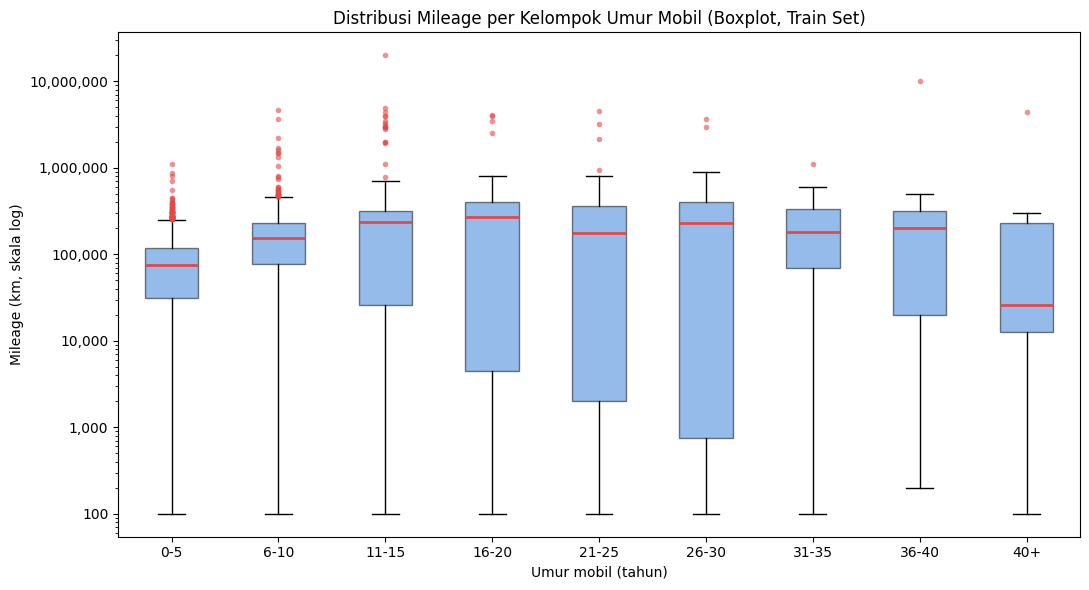

In [165]:
current_year = 2021
for d in (df_train, df_test):
    d['car_age'] = (current_year - d['Year']).clip(lower=0)

bins = [-1,5,10,15,20,25,30,35,40,100]
labels = ['0-5','6-10','11-15','16-20','21-25','26-30','31-35','36-40','40+']
for d in (df_train, df_test):
    d['age_group'] = pd.cut(d['car_age'], bins=bins, labels=labels)

# Visualisasi distribusi Mileage per age_group (train)
data_per_group = [df_train[df_train['age_group']==grp]['Mileage'].dropna().values for grp in labels]

fig, ax = plt.subplots(figsize=(11,6))
ax.boxplot(
    data_per_group,
    tick_labels=labels,
    patch_artist=True,
    flierprops=dict(marker='o', markerfacecolor='#e34948', markersize=4, markeredgecolor='none', alpha=0.6),
    medianprops=dict(color='#e34948', linewidth=2),
    boxprops=dict(facecolor='#2a78d6', alpha=0.5)
)
ax.set_xlabel('Umur mobil (tahun)')
ax.set_ylabel('Mileage (km, skala log)')
ax.set_title('Distribusi Mileage per Kelompok Umur Mobil (Boxplot, Train Set)')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [166]:
def fit_mileage_bounds(train_df):
    """Q1/Q3 upper bound per age_group, HANYA dari train."""
    bounds = {}
    for grp, g in train_df.groupby('age_group', observed=True):
        q1, q3 = g['Mileage'].quantile([0.25, 0.75])
        bounds[grp] = q3 + 1.5 * (q3 - q1)
    return bounds

def apply_mileage_outlier(d, bounds, fallback):
    ub = d['age_group'].map(bounds).astype(float)
    ub = ub.fillna(fallback)
    return d['Mileage'] > ub

mileage_bounds = fit_mileage_bounds(df_train)
overall_upper = pd.Series(mileage_bounds).median()  # fallback utk age_group yg tak ada di train

df_train['mileage_outlier'] = apply_mileage_outlier(df_train, mileage_bounds, overall_upper)
df_test['mileage_outlier'] = apply_mileage_outlier(df_test, mileage_bounds, overall_upper)

print(f"Mileage outlier - train: {df_train['mileage_outlier'].sum()} dari {len(df_train)} ({df_train['mileage_outlier'].mean()*100:.2f}%)")
print(f"Mileage outlier - test : {df_test['mileage_outlier'].sum()} dari {len(df_test)} ({df_test['mileage_outlier'].mean()*100:.2f}%)")

# Outlier ini TIDAK di-drop di sini, hanya ditandai (flag) -> dibuang nanti di Data Preparation

Mileage outlier - train: 140 dari 6444 (2.17%)
Mileage outlier - test : 39 dari 1620 (2.41%)


#### **3.6.2 Column Price**

Threshold (median Price per age_group, untuk baris berharga valid) di-*fit* hanya dari `df_train`.

In [167]:
train_valid_price = df_train[df_train['Price'] > 0]
median_by_age_train = train_valid_price.groupby('age_group', observed=True)['Price'].median()
overall_median = median_by_age_train.median()

def apply_price_outlier(d, median_map, fallback):
    med = d['age_group'].map(median_map).astype(float)
    med = med.fillna(fallback)
    valid = d['Price'] > 0
    ratio = d['Price'] / med
    flag = pd.Series(False, index=d.index)
    flag[valid] = ratio[valid] < 0.10
    return flag

df_train['price_outlier'] = apply_price_outlier(df_train, median_by_age_train, overall_median)
df_test['price_outlier'] = apply_price_outlier(df_test, median_by_age_train, overall_median)

n_valid_train = (df_train['Price'] > 0).sum()
n_valid_test = (df_test['Price'] > 0).sum()
print(f"Price outlier - train: {df_train['price_outlier'].sum()} dari {n_valid_train} baris berharga valid ({df_train['price_outlier'].sum()/n_valid_train*100:.2f}%)")
print(f"Price outlier - test : {df_test['price_outlier'].sum()} dari {n_valid_test} baris berharga valid ({df_test['price_outlier'].sum()/n_valid_test*100:.2f}%)")

# Outlier ini TIDAK di-drop di sini, hanya ditandai (flag) -> dibuang nanti di Data Preparation

Price outlier - train: 72 dari 4411 baris berharga valid (1.63%)
Price outlier - test : 15 dari 1113 baris berharga valid (1.35%)


C:\Users\Athiyyah\AppData\Local\Temp\ipykernel_12516\597513308.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  flag[valid] = ratio[valid] < 0.10
C:\Users\Athiyyah\AppData\Local\Temp\ipykernel_12516\597513308.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  flag[valid] = ratio[valid] < 0.10


## **Section 4. Exploratory Data Analysis (EDA)**

>   **Catatan metodologi:** EDA di bagian ini bersifat *deskriptif* - untuk memahami karakteristik data, bukan untuk mengambil keputusan preprocessing (keputusan itu sudah di-*fit* dari train saja di Section 3). Karena itu, EDA dijalankan di atas `df_full` (gabungan train+test kembali) supaya gambaran distribusi tetap representatif terhadap keseluruhan data yang tersedia.

In [168]:
df_train['__split__'] = 'train'
df_test['__split__'] = 'test'
df_full = pd.concat([df_train, df_test], axis=0)
print('df_full shape (untuk EDA deskriptif):', df_full.shape)

# alias 'df' dipakai di bawah supaya konsisten dengan penomoran sel notebook asli
df = df_full

df_full shape (untuk EDA deskriptif): (8064, 18)


### **4.1 Distribusi Data per Variabel**

#### **4.1.1 Distribusi Variabel Target**

Memeriksa distribusi variabel target (`Price`) sebelum dianalisis lebih lanjut, khususnya untuk mengidentifikasi dan mengukur dampak listing dengan status **"Price Negotiable"** yang di-encode sebagai `Price = 0` dalam dataset.

In [169]:
n_negotiable = (df['Price'] == 0).sum()
n_total = len(df)
print(f"Baris Price = 0 (dulunya 'Negotiable'): {n_negotiable} dari {n_total} ({n_negotiable/n_total*100:.2f}%)")
print()
print('Statistik Price (seluruh data, termasuk yang 0):')
print(df['Price'].describe())
print()
print('Statistik Price (hanya yang > 0, ini yang representatif buat harga asli):')
print(df.loc[df['Price'] > 0, 'Price'].describe())

Baris Price = 0 (dulunya 'Negotiable'): 2540 dari 8064 (31.50%)

Statistik Price (seluruh data, termasuk yang 0):
count    8.064000e+03
mean     5.373235e+04
std      7.265928e+04
min      0.000000e+00
25%      0.000000e+00
50%      3.700000e+04
75%      7.350000e+04
max      1.150000e+06
Name: Price, dtype: float64

Statistik Price (hanya yang > 0, ini yang representatif buat harga asli):
count    5.524000e+03
mean     7.843912e+04
std      7.595394e+04
min      1.000000e+00
25%      3.500000e+04
50%      5.800000e+04
75%      9.500000e+04
max      1.150000e+06
Name: Price, dtype: float64


### Interpretasi Output

Sebanyak **2.540 dari 8.064 baris (31,50%)** memiliki `Price = 0`, yang merepresentasikan listing berstatus *Negotiable* (harga belum ditentukan), bukan data yang hilang secara acak - ini dikonfirmasi oleh selisih `count` antara kedua tabel statistik (8.064 − 5.524 = 2.540), yang persis sama dengan jumlah baris negotiable.

Menyertakan nilai 0 dalam statistik deskriptif menyebabkan **bias signifikan ke bawah**:
- **Mean** turun dari **78.439** menjadi **53.732** (~31%, sebanding dengan proporsi negotiable)
- **Median** turun lebih tajam, dari **58.000** menjadi **37.000** (~36%), dan kuartil bawah (25%) pada data penuh bahkan jatuh ke **0** - membuatnya tidak informatif
- **Std** relatif tidak berubah (72.659 vs 75.953), menunjukkan bias terjadi pada *lokasi* distribusi (mean/median), bukan pada sebarannya
- **Max** tetap sama (1.150.000), karena outlier atas tidak berasal dari listing negotiable

**Kesimpulan:** statistik pada data penuh (termasuk 0) tidak layak dipakai untuk analisis harga. Versi `Price > 0` harus digunakan sebagai representasi harga asli, sementara listing *negotiable* perlu ditangani terpisah (di-exclude dari model regresi harga atau dimodelkan sebagai kasus/flag khusus).

---

Membuat dataset baru (`df_price`) yang hanya berisi listing dengan **harga asli** (`Price > 0`), sebagai tindak lanjut dari temuan sebelumnya bahwa nilai `Price = 0` merepresentasikan listing *Negotiable* dan bukan harga yang valid.

`df_price` ini akan menjadi dataset acuan untuk analisis distribusi harga dan pemodelan prediksi harga selanjutnya, terpisah dari listing negotiable.

In [170]:
df_price = df[df['Price'] > 0].copy()
print(f'df_price shape: {df_price.shape}')

df_price shape: (5524, 18)


### Interpretasi Output

`df_price` berisi **5.524 baris dan 18 kolom**, yaitu hasil filter dari total 8.064 baris setelah membuang 2.540 baris berstatus *Negotiable* (`Price = 0`).

Jumlah ini konsisten dengan temuan sebelumnya (8.064 − 2.540 = 5.524), mengonfirmasi bahwa proses filtering berjalan sesuai ekspektasi tanpa kehilangan atau duplikasi baris yang tidak diinginkan. Jumlah kolom tetap 18 (tidak ada kolom yang hilang), karena filter hanya dilakukan pada baris, bukan struktur kolom.

`df_price` siap digunakan sebagai dataset utama untuk analisis distribusi harga dan tahap pemodelan selanjutnya.

---

Memvisualisasikan variabel `Price` (harga valid) melalui pie chart (proporsi negotiable vs tercantum), histogram (bentuk distribusi), boxplot (outlier), dan skewness (ukuran kemencengan distribusi).

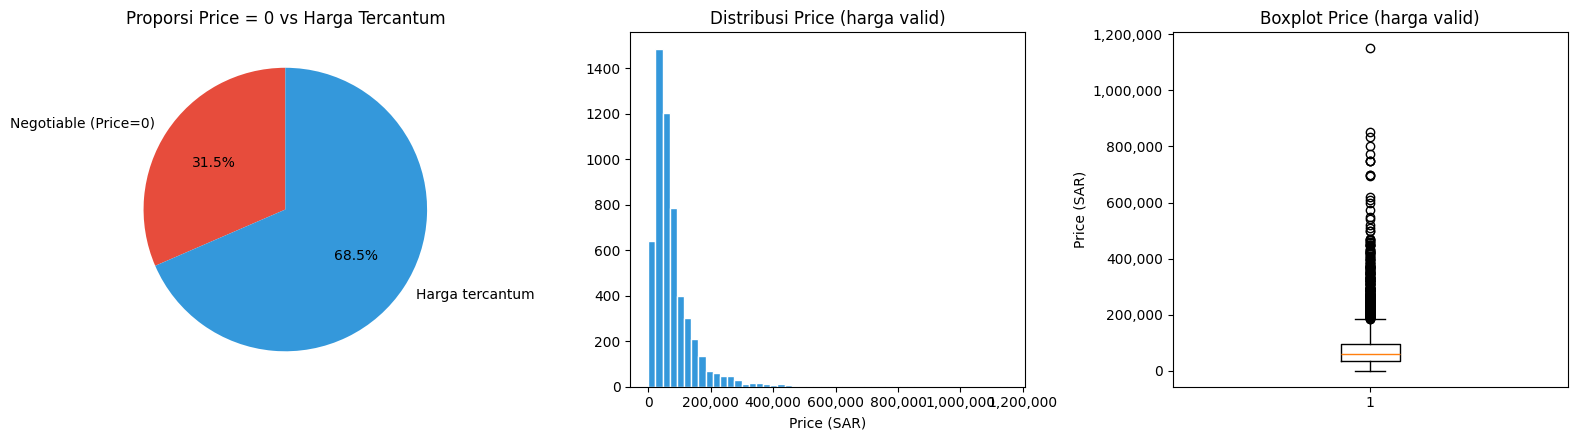

Skewness Price (harga valid): 3.73


In [171]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].pie(
    [n_negotiable, n_total - n_negotiable],
    labels=['Negotiable (Price=0)', 'Harga tercantum'],
    autopct='%1.1f%%', colors=['#e74c3c', '#3498db'], startangle=90
)
axes[0].set_title('Proporsi Price = 0 vs Harga Tercantum')

axes[1].hist(df_price['Price'], bins=50, color='#3498db', edgecolor='white')
axes[1].set_title('Distribusi Price (harga valid)')
axes[1].set_xlabel('Price (SAR)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[2].boxplot(df_price['Price'], vert=True)
axes[2].set_title('Boxplot Price (harga valid)')
axes[2].set_ylabel('Price (SAR)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print(f"Skewness Price (harga valid): {df_price['Price'].skew():.2f}")

### Interpretasi Output

**Pie chart** mengonfirmasi ulang temuan sebelumnya secara visual: **31,5%** listing berstatus *Negotiable* (Price=0), sedangkan **68,5%** memiliki harga tercantum.

**Histogram** menunjukkan distribusi `Price` yang **sangat menceng ke kanan (right-skewed)** - mayoritas mobil terkonsentrasi pada rentang harga rendah (di bawah 200.000 SAR), dengan frekuensi menurun tajam seiring naiknya harga, dan ekor panjang yang memanjang hingga ~1.200.000 SAR.

**Boxplot** memperkuat pola ini: median dan kotak (IQR) berada sangat rendah dan sempit, sementara terdapat **banyak outlier** di atas *upper whisker* - beberapa bahkan mendekati 1.200.000 SAR. Ini menunjukkan sebagian kecil listing mobil premium/mewah yang harganya jauh di atas mayoritas data.

**Skewness = 3,73** - nilai ini jauh di atas ambang umum untuk kategori "highly skewed" (>1), mengonfirmasi secara kuantitatif bahwa distribusi harga **tidak normal** dan sangat asimetris ke kanan.

**Implikasi:** untuk analisis atau pemodelan lebih lanjut (terutama model regresi), transformasi seperti **log-transform** pada `Price` kemungkinan diperlukan untuk mengurangi skewness dan menstabilkan varians, mengingat sebaran yang sangat tidak simetris ini bisa berdampak pada performa model dan interpretasi statistik (mean vs median).

---

#### **4.1.2 Distribusi Fitur Numerik**

Melihat statistik deskriptif fitur numerik (`Year`, `car_age`, `Mileage`, `Engine_Size`) untuk mengecek rentang nilai, pusat sebaran, dan potensi anomali/outlier sebelum analisis lebih lanjut.

In [172]:
num_cols = ['Year', 'car_age', 'Mileage', 'Engine_Size']
df[num_cols].describe()

,Year,car_age,Mileage,Engine_Size
count,8064.000000,8064.000000,8.064000e+03,8064.000000
mean,2014.099578,6.900670,1.495279e+05,3.292646
std,5.715777,5.715455,3.471260e+05,1.519557
min,1963.000000,0.000000,1.000000e+02,1.000000
25%,2012.000000,3.000000,3.700000e+04,2.000000
50%,2016.000000,5.000000,1.020000e+05,3.000000
75%,2018.000000,9.000000,1.950000e+05,4.500000
max,2022.000000,58.000000,2.000000e+07,9.000000


### Interpretasi Output

- **Year**: rentang 1963–2022, mean 2014 dan median 2016 lebih tinggi dari Q1 (2012) - didominasi listing mobil relatif baru, dengan sedikit unit sangat lama yang menarik mean ke bawah.
- **car_age**: mean 6,9 tahun, median 5 tahun, namun Q3 sudah 9 tahun - menunjukkan distribusi **menceng ke kanan** (right-skewed), sebagian kecil mobil sangat tua (usia puluhan tahun, konsisten dengan Year minimum 1963) menjadi outlier di ekor kanan.
- **Mileage**: mean 149.528 km dan median 102.000 km masih masuk akal, tapi **max 22.000.000 km** sangat tidak realistis untuk kendaraan biasa - ini indikasi kuat **data error/outlier ekstrem** yang perlu ditangani (capping, investigasi, atau exclude) sebelum dipakai untuk modeling. Std yang sangat besar (347.126) relatif terhadap mean juga mengonfirmasi adanya outlier signifikan.
- **Engine_Size**: rentang 1,0–9,0 liter, mean 3,29 - distribusi terlihat wajar tanpa anomali mencolok.

**Catatan tindak lanjut:** `Mileage` perlu pengecekan outlier lebih lanjut (misalnya boxplot/IQR atau domain threshold realistis, mis. maks ~500.000–1.000.000 km) sebelum digunakan dalam analisis atau model prediksi harga.

---

Memvisualisasikan distribusi keempat fitur numerik (`Year`, `car_age`, `Mileage`, `Engine_Size`) sekaligus dalam bentuk histogram untuk melihat bentuk sebaran dan mendeteksi anomali secara visual.

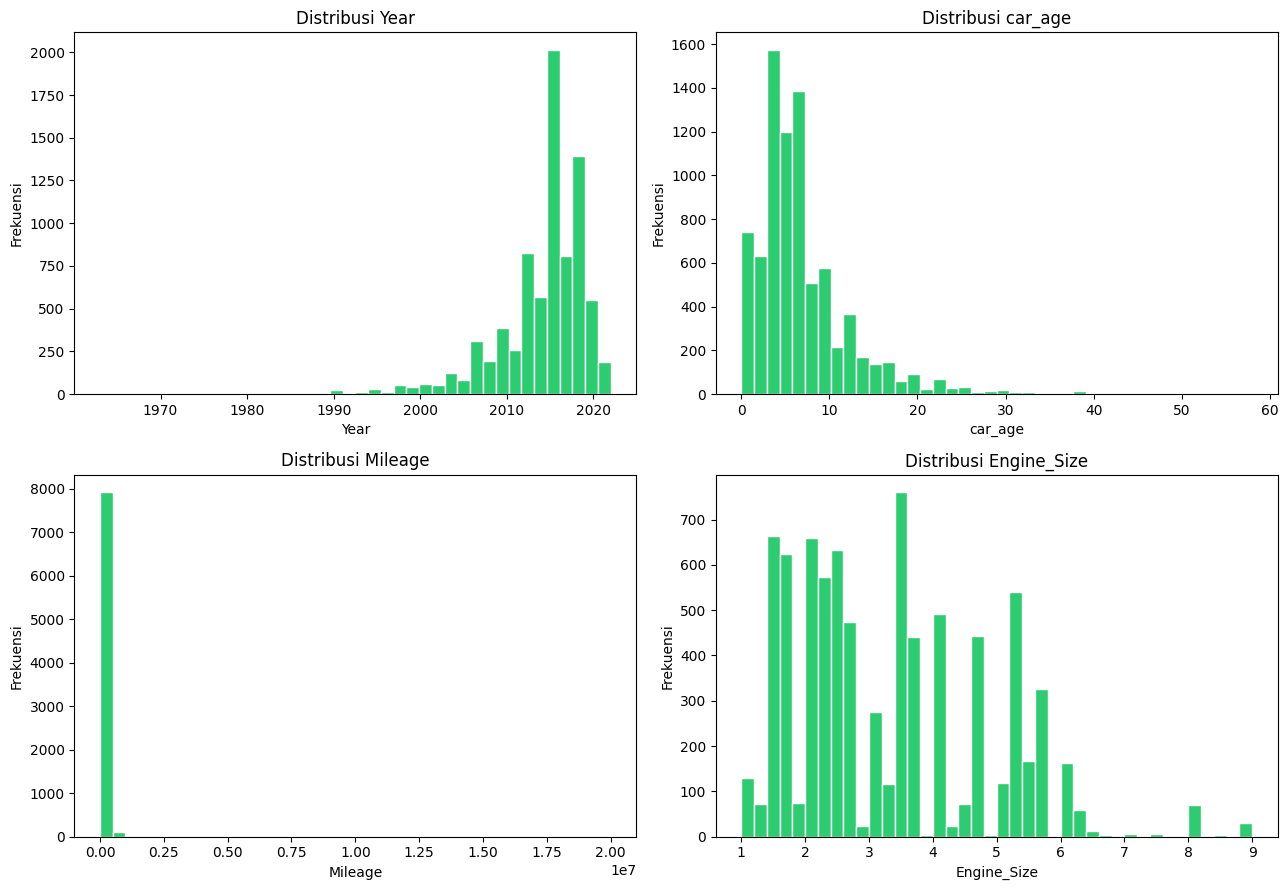

In [173]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=40, color='#2ecc71', edgecolor='white')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

### Interpretasi Output

- **Distribusi Year**: menceng ke kiri (left-skewed), didominasi listing tahun 2010–2022, dengan puncak di sekitar 2015–2016. Sedikit data tersebar dari 1963–2000 sebagai ekor panjang, konsisten dengan temuan statistik deskriptif sebelumnya.
- **Distribusi car_age**: menceng ke kanan (right-skewed) - sebagian besar mobil berusia 0–15 tahun, dengan ekor memanjang hingga ~50-60 tahun. Bentuknya adalah cerminan (mirror) dari distribusi `Year`, sesuai ekspektasi karena `car_age` diturunkan dari `Year`.
- **Distribusi Mileage**: **rusak secara visual** - hampir seluruh data mengumpul di satu bar dekat 0, sementara sumbu-x terentang sampai 2×10⁷ (20 juta km). Ini mengonfirmasi temuan sebelumnya bahwa ada **outlier ekstrem** (max 22 juta km) yang mendominasi skala plot, sehingga histogram tidak informatif dalam bentuk saat ini. Perlu **penanganan outlier** (capping/exclude) atau **transformasi log** sebelum divisualisasikan ulang agar bentuk distribusi sebenarnya terlihat.
- **Distribusi Engine_Size**: multimodal dengan beberapa puncak jelas (sekitar 2, 3.5, dan 5 liter) - mencerminkan ukuran mesin standar yang umum di pasaran, bukan distribusi kontinu yang mulus. Wajar dan tidak menunjukkan anomali.

**Catatan tindak lanjut:** histogram `Mileage` perlu dibuat ulang setelah outlier ditangani, agar sebaran mayoritas data (yang saat ini tertutup oleh skala outlier) bisa terlihat dengan jelas.

---

#### **4.1.3 Distribusi Fitur Kategorikal**

Melihat sebaran merek mobil (`Make`) yang paling banyak muncul dalam listing, untuk memahami komposisi pasar dan tingkat konsentrasi/dominasi merek tertentu dalam dataset.

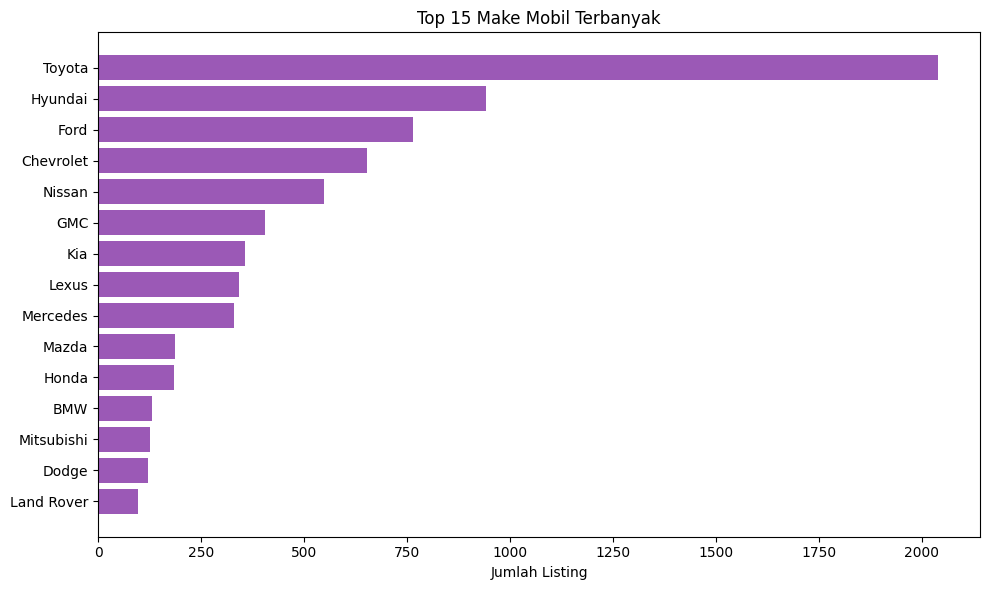

Total Make unik: 57


In [174]:
top_n = 15

fig, ax = plt.subplots(figsize=(10, 6))
make_counts = df['Make'].value_counts().head(top_n)
ax.barh(make_counts.index[::-1], make_counts.values[::-1], color='#9b59b6')
ax.set_title(f'Top {top_n} Make Mobil Terbanyak')
ax.set_xlabel('Jumlah Listing')
plt.tight_layout()
plt.show()

print(f"Total Make unik: {df['Make'].nunique()}")

### Interpretasi Output

Dari total **57 merek unik**, distribusi sangat **tidak merata** dan didominasi segelintir merek:

- **Toyota** jauh mendominasi dengan ~2.000 listing, hampir 3× lipat merek di posisi kedua.
- **Hyundai** dan **Ford** menyusul di kisaran 650–750 listing, diikuti **Chevrolet** dan **Nissan** di kisaran 450–550.
- Merek-merek premium seperti **Lexus, Mercedes, BMW** hadir dengan jumlah jauh lebih kecil (~100–200 listing), wajar mengingat segmen mobil mewah biasanya lebih sedikit populasinya di pasar sekunder.
- Sisanya (42 merek di luar top 15) berkontribusi jumlah listing yang relatif kecil - menunjukkan **long tail** khas data kategorikal dengan banyak kelas minor.

**Implikasi:** dominasi Toyota yang ekstrem berpotensi menyebabkan **class imbalance** bila `Make` dipakai sebagai fitur kategorikal dalam model. Perlu dipertimbangkan strategi seperti *grouping* merek minor menjadi kategori "Other", atau target encoding, agar model tidak bias terhadap merek mayoritas.

---

Melihat sebaran tiga fitur kategorikal (`Fuel_Type`, `Gear_Type`, `Options`) untuk memahami komposisi kategori dan tingkat dominasi masing-masing kelas dalam dataset.

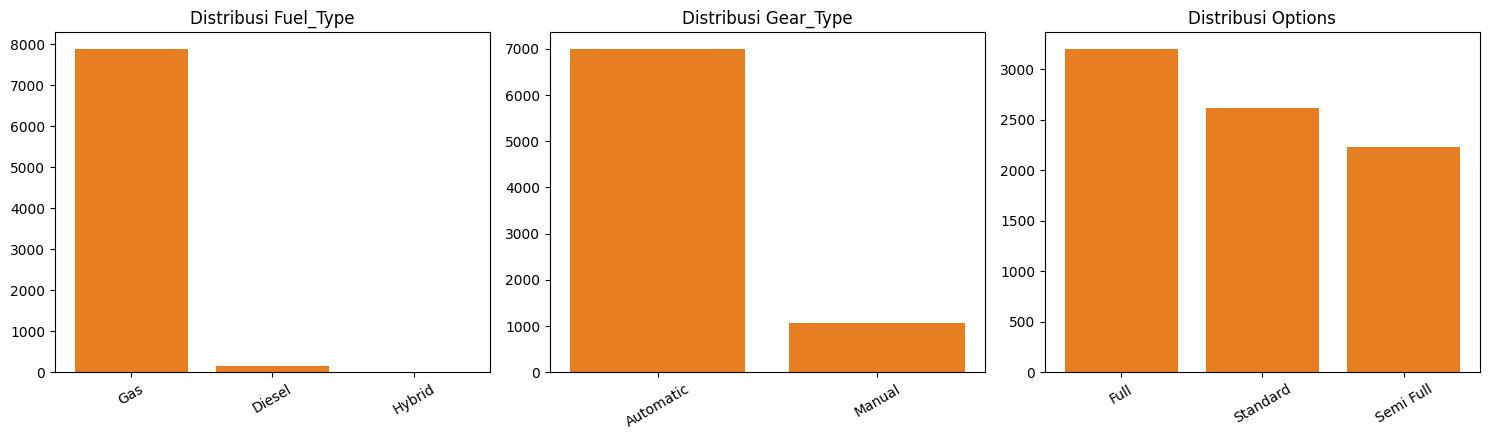

In [175]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col in zip(axes, ['Fuel_Type', 'Gear_Type', 'Options']):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color='#e67e22')
    ax.set_title(f'Distribusi {col}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Interpretasi Output

- **Fuel_Type**: sangat **didominasi Gas** (~7.900 listing), sementara **Diesel** hanya sedikit dan **Hybrid** nyaris tidak terlihat (mendekati 0). Ini indikasi **class imbalance ekstrem** - fitur ini kemungkinan kurang berguna untuk membedakan harga secara statistik kecuali kategori minor digabung atau dianalisis terpisah.
- **Gear_Type**: didominasi **Automatic** (~7.000) dibanding **Manual** (~1.000), rasio sekitar 7:1. Wajar untuk pasar mobil modern, namun tetap perlu diwaspadai saat dipakai sebagai fitur karena representasi Manual relatif kecil.
- **Options**: distribusi paling **merata** di antara ketiganya - **Full** (~3.150), **Standard** (~2.650), **Semi Full** (~2.250) - tidak ada dominasi ekstrem, sehingga fitur ini kemungkinan lebih informatif dan seimbang untuk digunakan dalam analisis maupun model.

**Implikasi:** `Fuel_Type` dan `Gear_Type` berisiko menyebabkan bias/tidak signifikan secara statistik akibat imbalance saat one-hot encoding atau uji beda rata-rata harga antar kategori (kategori minor punya sampel terlalu kecil untuk kesimpulan yang kuat). `Options` relatif aman digunakan langsung.

---

Melihat sebaran fitur geografis `Origin` (asal mobil) dan `Region` (wilayah listing) untuk memahami komposisi pasar berdasarkan lokasi.

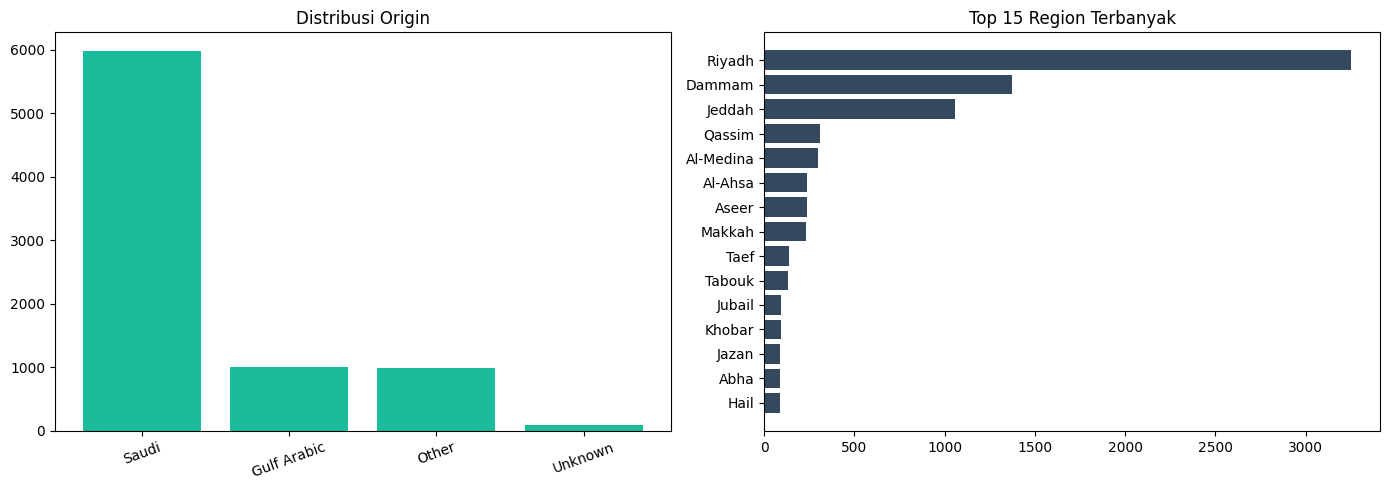

Total Region unik: 27


In [176]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

origin_vc = df['Origin'].value_counts()
axes[0].bar(origin_vc.index, origin_vc.values, color='#1abc9c')
axes[0].set_title('Distribusi Origin')
axes[0].tick_params(axis='x', rotation=20)

region_vc = df['Region'].value_counts().head(top_n)
axes[1].barh(region_vc.index[::-1], region_vc.values[::-1], color='#34495e')
axes[1].set_title(f'Top {top_n} Region Terbanyak')

plt.tight_layout()
plt.show()

print(f"Total Region unik: {df['Region'].nunique()}")

### Interpretasi Output

- **Distribusi Origin**: didominasi **Saudi** (~6.100 listing), jauh di atas **Gulf Arabic** dan **Other** (masing-masing ~950–1.000), sementara **Unknown** sangat kecil (<100). Konsisten dengan konteks bisnis Syarah.com sebagai marketplace mobil di pasar Saudi - wajar bila mayoritas unit berasal dari origin lokal.
- **Distribusi Region**: dari total **27 region unik**, **Riyadh** mendominasi drastis (~3.100 listing), disusul **Dammam** (~1.150) dan **Jeddah** (~900) - tiga kota besar ini bersama-sama menguasai porsi signifikan dari total listing. Sisanya (region ke-4 dan seterusnya) menurun tajam ke kisaran ratusan, membentuk **long tail** khas data geografis yang terpusat di kota-kota metropolitan.

**Implikasi:** kedua fitur menunjukkan **konsentrasi tinggi pada kategori mayoritas**. Untuk `Region` khususnya, dengan 27 kategori dan distribusi yang sangat timpang, perlu dipertimbangkan **grouping region minor** (mis. jadi "Other Region") sebelum digunakan sebagai fitur kategorikal dalam model, agar tidak menghasilkan terlalu banyak dummy variable dengan sampel kecil per kelas.

---

Menguji normalitas distribusi tiga fitur numerik (`car_age`, `Mileage`, `Engine_Size`) menggunakan **Shapiro-Wilk test**, untuk menentukan apakah data mengikuti distribusi normal - hasil ini menjadi dasar pemilihan metode statistik lanjutan (parametrik vs non-parametrik) dan kebutuhan transformasi data.

In [177]:
# Uji Normalitas Fitur Numerik
numeric_features = ['car_age', 'Mileage', 'Engine_Size']

normality_results = {}
for col in numeric_features:
    data_sample = df_price[col].dropna().sample(min(5000, len(df_price)), random_state=42)
    stat, p_value = shapiro(data_sample)
    normality_results[col] = {'Shapiro_Statistic': stat, 'p-value': p_value}

normality_df = pd.DataFrame(normality_results).T.sort_values(by='p-value', ascending=True)
display(normality_df)

,Shapiro_Statistic,p-value
Mileage,0.176579,2.630718e-91
car_age,0.786309,7.592976e-63
Engine_Size,0.929968,2.095732e-43


### Interpretasi Output

Ketiga fitur memiliki **p-value jauh di bawah 0,05**, sehingga hipotesis nol (data berdistribusi normal) **ditolak untuk semuanya**:

- **Mileage**: Shapiro statistic paling rendah (**0,1766**) dengan p-value **~2,63e-91** - penyimpangan dari normal paling ekstrem di antara ketiganya, konsisten dengan temuan sebelumnya soal outlier ekstrem pada kolom ini.
- **car_age**: statistic **0,7863**, p-value **~7,59e-63** - jelas tidak normal, sejalan dengan pola right-skewed yang terlihat di histogram sebelumnya.
- **Engine_Size**: statistic **0,9299** (paling mendekati 1 di antara ketiganya, meski tetap jauh dari normal), p-value **~1,99e-43** - pola multimodal yang terlihat di histogram sebelumnya menjelaskan mengapa distribusinya tidak normal meski relatif lebih "rapi" dibanding dua fitur lain.

**Catatan:** dengan n yang besar (sampel hingga 5.000 baris), Shapiro-Wilk sangat sensitif dan hampir selalu menghasilkan p-value signifikan meski penyimpangan dari normal kecil - sehingga statistic value (bukan hanya p-value) lebih informatif untuk menilai *derajat* ketidaknormalan di sini.

**Implikasi:** karena tidak ada fitur numerik yang berdistribusi normal, uji korelasi/perbandingan sebaiknya menggunakan metode **non-parametrik** (mis. Spearman untuk korelasi, Mann-Whitney/Kruskal-Wallis untuk perbandingan grup) daripada metode berbasis asumsi normal (Pearson, t-test, ANOVA klasik).

---

Menguji korelasi antara masing-masing fitur numerik (`car_age`, `Mileage`, `Engine_Size`) dengan `Price` menggunakan **Spearman correlation** (non-parametrik), sesuai dengan hasil uji normalitas sebelumnya yang menunjukkan ketiga fitur tidak berdistribusi normal.

In [178]:
print("=== Spearman Correlation Test: Fitur Numerik vs Price ===\n")
for col in numeric_features:
    rho, p_value = spearmanr(df_price[col], df_price['Price'])
    kesimpulan = "Tolak H0 (signifikan)" if p_value < 0.05 else "Gagal tolak H0 (tidak signifikan)"
    print(f"{col:15s} -> rho = {rho:.4f}, p-value = {p_value:.4e} -> {kesimpulan}")

=== Spearman Correlation Test: Fitur Numerik vs Price ===

car_age         -> rho = -0.4236, p-value = 1.9597e-239 -> Tolak H0 (signifikan)
Mileage         -> rho = -0.2702, p-value = 4.9795e-93 -> Tolak H0 (signifikan)
Engine_Size     -> rho = 0.3798, p-value = 4.2367e-189 -> Tolak H0 (signifikan)


### Interpretasi Output

Ketiga fitur menunjukkan korelasi yang **signifikan secara statistik** (p-value jauh di bawah 0,05) terhadap `Price`:

- **car_age**: rho = **-0,4236** (korelasi negatif moderat) - semakin tua usia mobil, semakin rendah harganya. Ini korelasi terkuat di antara ketiganya, sesuai ekspektasi domain (depresiasi mobil seiring usia).
- **Mileage**: rho = **-0,2702** (korelasi negatif lemah-moderat) - semakin tinggi jarak tempuh, harga cenderung lebih rendah, meski hubungannya tidak sekuat `car_age`.
- **Engine_Size**: rho = **0,3796** (korelasi positif moderat) - mesin lebih besar cenderung berasosiasi dengan harga lebih tinggi, kemungkinan mencerminkan segmen mobil yang lebih premium/performa tinggi.

**Kesimpulan:** ketiga fitur numerik relevan dan layak dipertahankan sebagai prediktor dalam model harga, dengan `car_age` sebagai prediktor tunggal terkuat, diikuti `Engine_Size`, lalu `Mileage`. Arah korelasi (negatif untuk usia & jarak tempuh, positif untuk ukuran mesin) juga konsisten dengan intuisi bisnis di industri otomotif, memperkuat validitas fitur-fitur ini.

---

### **4.2 Hubungan Fitur dengan Target**

Memvisualisasikan hubungan antara `Price` dengan `car_age` dan `Mileage` melalui scatter plot, untuk melihat pola/bentuk hubungan secara visual sebagai pelengkap hasil uji korelasi Spearman sebelumnya.

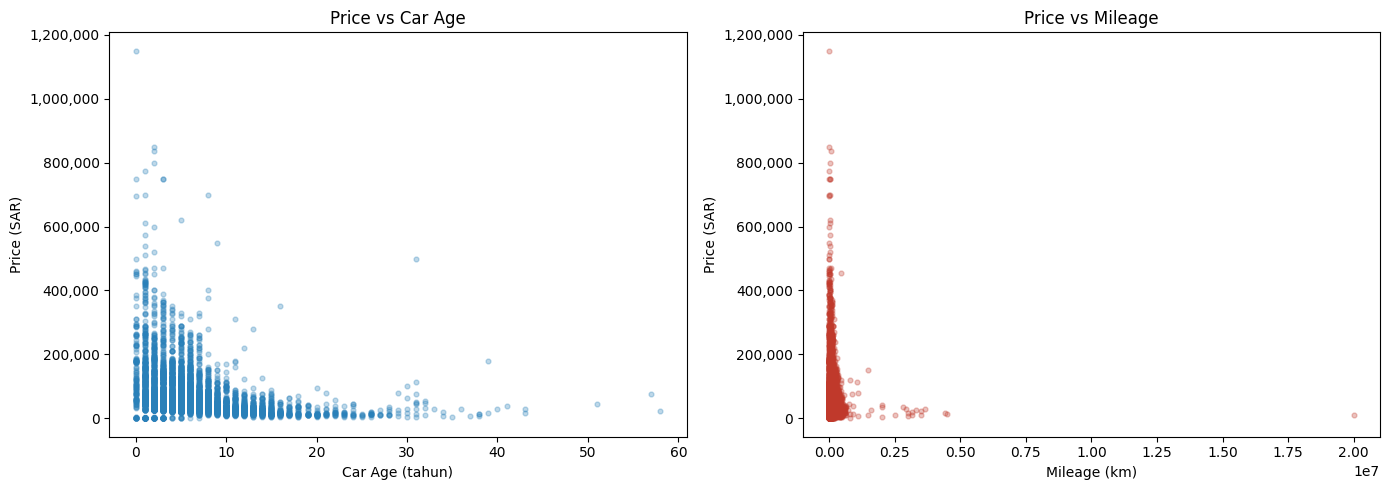

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_price['car_age'], df_price['Price'], alpha=0.3, s=12, color='#2980b9')
axes[0].set_title('Price vs Car Age')
axes[0].set_xlabel('Car Age (tahun)')
axes[0].set_ylabel('Price (SAR)')

axes[1].scatter(df_price['Mileage'], df_price['Price'], alpha=0.3, s=12, color='#c0392b')
axes[1].set_title('Price vs Mileage')
axes[1].set_xlabel('Mileage (km)')
axes[1].set_ylabel('Price (SAR)')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### Interpretasi Output

- **Price vs Car Age**: menunjukkan pola **penurunan harga non-linear** - harga tertinggi dan variasi terbesar terjadi pada mobil usia 0–10 tahun, lalu turun tajam dan menyempit setelah usia ~15-20 tahun, membentuk kurva mirip **eksponensial/depresiasi** khas mobil. Ini konsisten dengan korelasi Spearman negatif (rho = -0,42) yang tercatat sebelumnya - namun karena polanya non-linear, korelasi Spearman (berbasis ranking) lebih tepat menangkap hubungan ini dibanding Pearson.
- **Price vs Mileage**: pola serupa namun lebih ekstrem - mayoritas titik data mengumpul rapat di dekat **Mileage = 0**, sementara sumbu-x terentang hingga 2×10⁷ akibat outlier ekstrem (konsisten dengan temuan `Mileage` sebelumnya). Ini membuat visualisasi **kurang informatif** dalam skala saat ini karena mayoritas hubungan yang sebenarnya "tertekan" di ujung kiri plot.

**Implikasi:** untuk visualisasi `Price vs Mileage` yang lebih informatif, disarankan menangani outlier ekstrem pada `Mileage` (capping/filtering) atau menggunakan **transformasi log** pada sumbu Mileage, agar sebaran mayoritas data terlihat jelas dan pola hubungan sebenarnya dengan `Price` dapat dianalisis lebih akurat.

---

Membandingkan sebaran `Price` di antara kategori pada tiga fitur kategorikal (`Fuel_Type`, `Gear_Type`, `Options`) menggunakan boxplot, untuk melihat apakah kategori tertentu berasosiasi dengan harga yang lebih tinggi/rendah serta pola outlier di masing-masing kelompok.

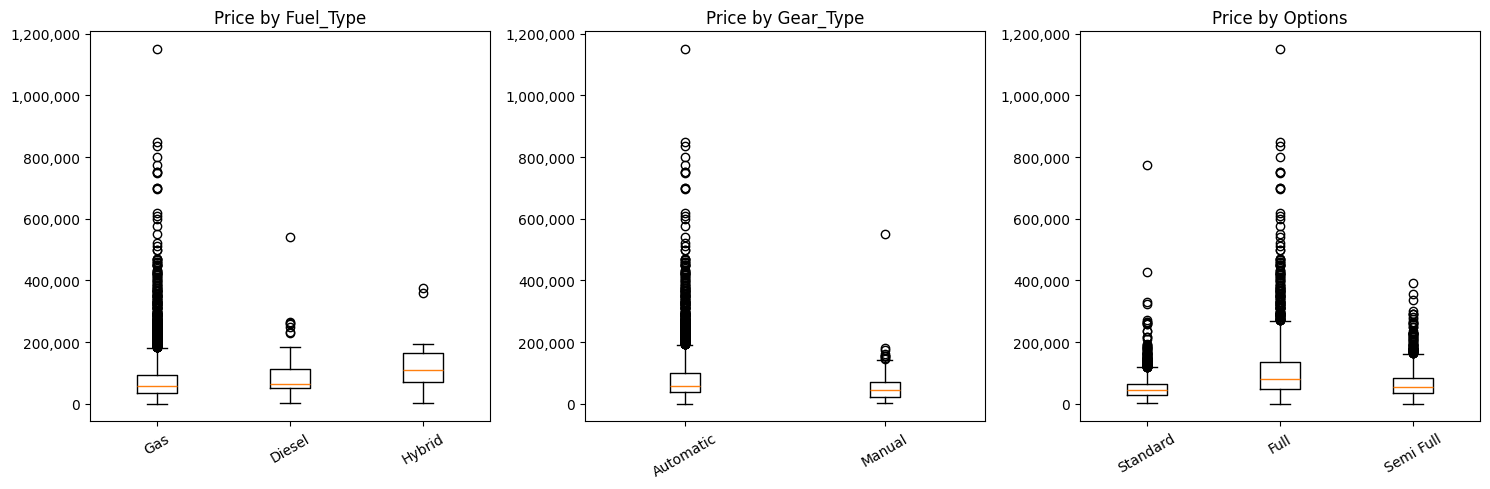

In [180]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Fuel_Type', 'Gear_Type', 'Options']):
    groups = [df_price[df_price[col] == cat]['Price'].values for cat in df_price[col].unique()]
    ax.boxplot(groups, tick_labels=df_price[col].unique())
    ax.set_title(f'Price by {col}')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### Interpretasi Output

- **Price by Fuel_Type**: **Gas** memiliki rentang harga terluas dengan outlier terbanyak dan tertinggi (hingga ~1.200.000), wajar karena jumlah sampelnya jauh lebih besar dari kategori lain. **Diesel** dan **Hybrid** memiliki box yang relatif lebih sempit dengan outlier lebih sedikit - namun perbandingan ini perlu hati-hati karena kedua kategori tersebut jumlah sampelnya sangat kecil (temuan sebelumnya menunjukkan Diesel dan Hybrid nyaris tidak terlihat di distribusi Fuel_Type).
- **Price by Gear_Type**: **Automatic** menunjukkan sebaran harga jauh lebih luas dengan outlier ekstrem hingga ~1.200.000, sementara **Manual** memiliki box lebih rendah dan sempit dengan hanya sedikit outlier. Ini mengindikasikan mobil bertransmisi Automatic cenderung mencakup segmen harga yang lebih beragam (termasuk mobil premium), sejalan dengan dominasi jumlah sampelnya.
- **Price by Options**: ketiga kategori (**Standard, Full, Semi Full**) memiliki pola yang relatif mirip dari segi rentang box, namun **Full** menunjukkan median dan outlier tertinggi (hingga ~1.200.000), diikuti **Standard**, lalu **Semi Full** dengan sebaran sedikit lebih rendah - mengindikasikan opsi kelengkapan mobil yang lebih tinggi berasosiasi dengan harga yang lebih tinggi pula.

**Catatan:** perbandingan antar kategori dengan jumlah sampel timpang (seperti Fuel_Type dan Gear_Type) berisiko kurang representatif secara statistik untuk kategori minor - sebaiknya dikonfirmasi dengan uji statistik non-parametrik (mis. Kruskal-Wallis) daripada hanya mengandalkan interpretasi visual boxplot.

---

Mengidentifikasi merek mobil (`Make`) dengan rata-rata `Price` tertinggi dan terendah, untuk memahami segmentasi harga antar merek dalam dataset.

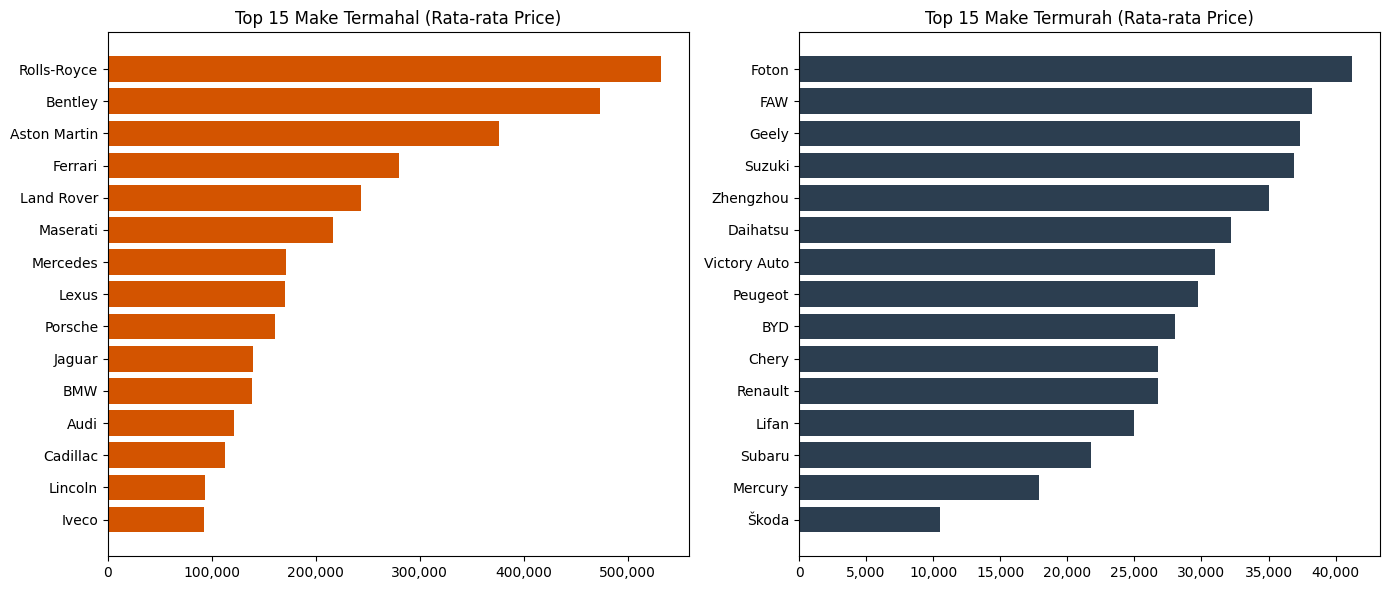

In [181]:
avg_price_make = df_price.groupby('Make', observed=True)['Price'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_expensive = avg_price_make.head(top_n)
axes[0].barh(top_expensive.index[::-1], top_expensive.values[::-1], color='#d35400')
axes[0].set_title(f'Top {top_n} Make Termahal (Rata-rata Price)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

top_cheap = avg_price_make.tail(top_n)
axes[1].barh(top_cheap.index[::-1], top_cheap.values[::-1], color='#2c3e50')
axes[1].set_title(f'Top {top_n} Make Termurah (Rata-rata Price)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### Interpretasi Output

- **Top 15 Make Termahal**: didominasi merek **mobil mewah/luxury** - **Rolls-Royce** (~500.000 SAR) jauh di atas merek lain, disusul **Bentley** (~420.000) dan **Aston Martin** (~370.000). Pola ini sangat masuk akal secara domain dan mengonfirmasi bahwa dataset mencakup segmen mobil premium/eksotis, konsisten dengan outlier ekstrem yang terlihat pada distribusi `Price` sebelumnya (hingga ~1.150.000 SAR).
- **Top 15 Make Termurah**: didominasi merek **entry-level/komersial**, terutama merek asal **China** (Foton, FAW, Geely, Zhengzhou, Chery, Lifan) dan merek budget lain (Suzuki, Daihatsu, Peugeot) - rata-rata harga di kisaran **10.000–40.000 SAR**, jauh di bawah kelompok termahal.

**Catatan penting:** perbandingan rata-rata harga ini rentan **bias karena jumlah sampel per merek tidak merata** - merek eksotis (Rolls-Royce, Bentley, dll.) kemungkinan hanya memiliki sedikit listing, sehingga rata-ratanya sensitif terhadap outlier individual. Perlu ditampilkan juga `count` per merek (atau gunakan median sebagai pembanding) agar interpretasi tidak menyesatkan - merek dengan sampel sangat kecil sebaiknya diberi catatan kehati-hatian atau di-exclude dari perbandingan ini.

**Implikasi:** `Make` terbukti menjadi fitur yang **sangat prediktif** terhadap `Price`, dengan rentang rata-rata harga yang sangat lebar (~10.000 hingga ~500.000 SAR) antar merek - memperkuat kelayakannya sebagai fitur penting dalam model prediksi harga, dengan catatan penanganan khusus untuk merek bersampel kecil.

---

### **4.3 Hubungan Antar Fitur Numerik**

#### **4.3.1 Pemeriksaan Korelasi (Visual)**

Memeriksa korelasi (Pearson) antar fitur numerik dan `Price` menggunakan heatmap, untuk mendeteksi hubungan linear serta potensi **multikolinearitas** antar fitur sebelum masuk tahap pemodelan.

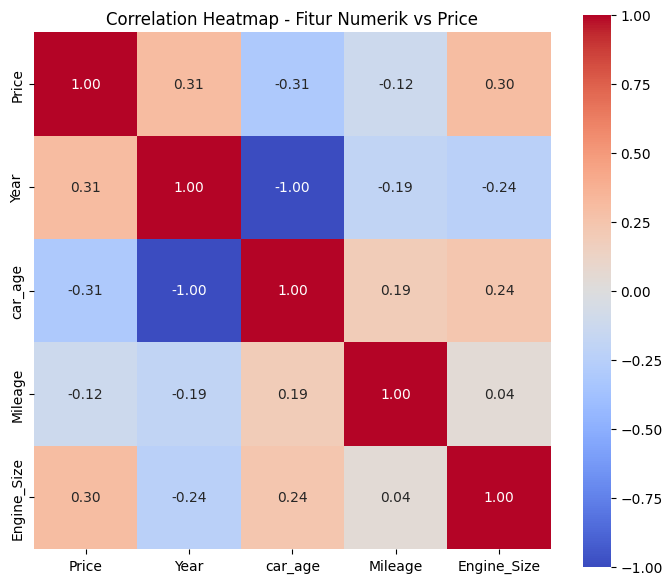

Price          1.000000
Year           0.312385
Engine_Size    0.302251
Mileage       -0.119042
car_age       -0.312385
Name: Price, dtype: float64

In [182]:
corr_cols = ['Price', 'Year', 'car_age', 'Mileage', 'Engine_Size']
corr_matrix = df_price[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap - Fitur Numerik vs Price')
plt.tight_layout()
plt.show()

corr_matrix['Price'].sort_values(ascending=False)

### Interpretasi Output

**Korelasi dengan Price** (dari terkuat): `Year` (0,31) ≈ `Engine_Size` (0,30) > `car_age` (-0,31) > `Mileage` (-0,12). Nilainya relatif lemah-moderat secara Pearson - sedikit lebih rendah dibanding hasil Spearman sebelumnya (rho car_age = -0,42), sesuai ekspektasi karena hubungan `Price` dengan fitur-fitur ini bersifat non-linear (sudah terlihat di scatter plot sebelumnya), sehingga Pearson kurang optimal menangkapnya dibanding Spearman.

**Temuan kritis - Multikolinearitas ekstrem:** `Year` dan `car_age` memiliki korelasi **-1,00 (sempurna)**. Ini bukan kebetulan - `car_age` kemungkinan besar **diturunkan langsung dari `Year`** (mis. `car_age = tahun_sekarang - Year`), sehingga keduanya membawa informasi yang sama persis, hanya berlawanan arah.

**Implikasi:** untuk pemodelan (terutama model linear/regresi), **`Year` dan `car_age` tidak boleh dipakai bersamaan** sebagai fitur - akan menyebabkan multikolinearitas sempurna dan membuat koefisien model tidak stabil/tidak dapat diinterpretasikan. Harus dipilih **salah satu saja**. `car_age` sedikit lebih disarankan karena maknanya lebih intuitif untuk interpretasi bisnis (usia mobil), kecuali ada alasan khusus untuk mempertahankan `Year` (mis. menangkap efek tren tahun tertentu).

Fitur lain (`Mileage`, `Engine_Size`) tidak menunjukkan korelasi tinggi terhadap fitur lain (semua di bawah 0,25), sehingga relatif aman dari isu multikolinearitas.

---

#### **4.3.2 Pemeriksaan Multikolinearitas (Skor VIF)**

| Rentang VIF | Interpretasi |
|---|---|
| VIF < 5 | Aman, multikolinearitas rendah |
| VIF 5–10 | Mulai perlu diwaspadai |
| VIF > 10 | Multikolinearitas tinggi, bermasalah untuk model yang sensitif terhadap ini (misal regresi linear) |

In [183]:
num_features = ['Year', 'car_age', 'Mileage', 'Engine_Size']  # tanpa 'Price', karena Price target bukan fitur
x_vif = df_price[num_features]

vif_score = pd.DataFrame()
vif_score["Feature"] = x_vif.columns
vif_score["VIF"] = [
    variance_inflation_factor(x_vif.values, i)
    for i in range(x_vif.shape[1])
]

vif_score

,Feature,VIF
0,Year,6.224955
1,car_age,2.701671
2,Mileage,1.038685
3,Engine_Size,1.058586


**Insight:**
- `Year` punya VIF di rentang 5–10, artinya mulai perlu diwaspadai (borderline), sedangkan `car_age`, `Mileage`, dan `Engine_Size` semuanya di bawah 5 sehingga aman.
Ini konsisten dengan temuan korelasi sebelumnya, bahwa `Year` dan `car_age` membawa informasi yang sama (korelasi mendekati -1), jadi keduanya tidak boleh dipakai bersamaan sebagai fitur.
- Tidak ada indikasi multikolinearitas ekstrem (VIF > 10) di antara fitur numerik lainnya - jadi `Mileage` dan `Engine_Size` aman digunakan bersamaan.
- Kesimpulan: cukup pilih salah satu dari `Year`/`car_age` (dan notebook memilih car_age karena lebih interpretable), lalu drop `Year` dari fitur modeling.

### **Ringkasan Temuan EDA**

- `Price` (harga valid) sangat *right-skewed* → perlu transformasi log sebelum modeling.
- `car_age` dan `Year` kolinear sempurna secara definisi (`car_age = 2021 - Year`) → VIF antar keduanya sangat tinggi, sesuai dugaan. Hanya `car_age` yang dipakai di pipeline modeling (Year di-drop otomatis oleh `CarAgeTransformer`).
- `car_age` dan `Mileage` berkorelasi signifikan (Spearman) dengan `Price`.
- Sebaran `Make` dan `Region` sangat tidak merata (beberapa kategori mendominasi) → alasan dipilihnya frequency encoding untuk kolom kardinalitas tinggi (`Make`, `Type`, `Region`).

## **Section 5. Data Preparation**

>   **Catatan revisi:** Section "Data Transformation" manual (encoding manual + scaling manual) yang ada di notebook sebelumnya **dihapus** di versi ini. Kode itu menghasilkan `X_train_enc`/`X_test_scaled` yang ternyata tidak pernah dipakai di proses modeling - satu-satunya preprocessing yang benar-benar dipakai adalah pipeline sklearn (`ColumnTransformer` + custom transformer) di Section 6.2. Menghapusnya menghindari kebingungan pembaca notebook.

### Finalisasi Dataset untuk Modeling

Difinalisasi terpisah untuk `df_train` dan `df_test`

In [184]:
def finalize(d):
    d = d.copy()
    d = d[d['Price'] > 0]                 # buang listing Negotiable (Price=0)
    d = d[~d['mileage_outlier'].astype(bool)]
    d = d[~d['price_outlier'].astype(bool)]
    drop_cols = ['car_age', 'Negotiable', 'age_group', 'mileage_outlier', 'price_outlier']
    if '__split__' in d.columns:
        drop_cols.append('__split__')
    d = d.drop(columns=drop_cols)
    d = d.reset_index(drop=True)
    return d

print(f'Shape df_train sebelum finalisasi: {df_train.shape}')
print(f'Shape df_test  sebelum finalisasi: {df_test.shape}')

df_train_model = finalize(df_train)
df_test_model = finalize(df_test)

print(f'\nShape df_train_model final: {df_train_model.shape}')
print(f'Shape df_test_model final : {df_test_model.shape}')
df_train_model.head()

Shape df_train sebelum finalisasi: (6444, 18)
Shape df_test  sebelum finalisasi: (1620, 18)

Shape df_train_model final: (4257, 12)
Shape df_test_model final : (1079, 12)


,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price
0,Toyota,Corolla,2016,Saudi,Silver,Standard,1.6,Gas,Automatic,190000,Abha,32000
1,Nissan,Patrol,2016,Saudi,White,Full,5.6,Gas,Automatic,139000,Riyadh,158000
2,Mercedes,S,2002,Gulf Arabic,Golden,Semi Full,3.0,Gas,Automatic,348,Al-Ahsa,12500
3,Chevrolet,Malibu,2017,Saudi,White,Semi Full,2.5,Gas,Automatic,175000,Dammam,49000
4,Lexus,ES,2017,Other,Golden,Full,3.5,Gas,Automatic,34593,Riyadh,148000


In [185]:
# Gabungkan kembali train & test jadi satu dataset final
df_clean_final = pd.concat([df_train_model, df_test_model], axis=0).reset_index(drop=True)

# Simpan ke folder data/processed sebagai single source of truth
os.makedirs("../data/processed", exist_ok=True)
df_clean_final.to_csv("../data/processed/UsedCarsSA_Clean_FINAL.csv", index=False)
print(f"Data clean tersimpan: {df_clean_final.shape} -> ../data/processed/UsedCarsSA_Clean_FINAL.csv")

Data clean tersimpan: (5336, 12) -> ../data/processed/UsedCarsSA_Clean_FINAL.csv


In [186]:
df_train_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4257 entries, 0 to 4256
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         4257 non-null   object 
 1   Type         4257 non-null   object 
 2   Year         4257 non-null   int64  
 3   Origin       4257 non-null   object 
 4   Color        4257 non-null   object 
 5   Options      4257 non-null   object 
 6   Engine_Size  4257 non-null   float64
 7   Fuel_Type    4257 non-null   object 
 8   Gear_Type    4257 non-null   object 
 9   Mileage      4257 non-null   int64  
 10  Region       4257 non-null   object 
 11  Price        4257 non-null   int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 399.2+ KB


### **5.1 Constructing `X`/`y`**

In [187]:
X_train = df_train_model.drop(columns=['Price'])
y_train = df_train_model['Price']
X_test = df_test_model.drop(columns=['Price'])
y_test = df_test_model['Price']

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')

X_train: (4257, 11), X_test: (1079, 11)
y_train: (4257,), y_test: (1079,)


### **5.2 Transform Log Target**

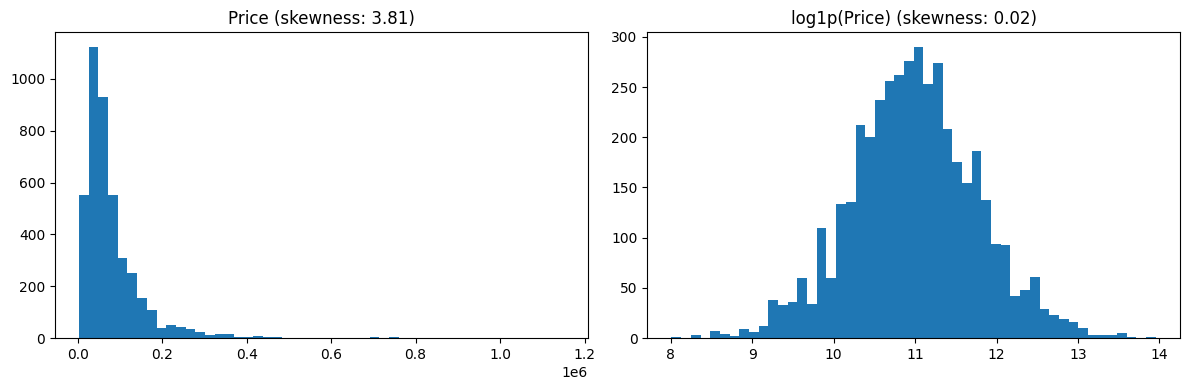

In [188]:
# Transform target - dilakukan setelah split, sebelum masuk ke preprocessing/modeling
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=50)
axes[0].set_title(f'Price (skewness: {y_train.skew():.2f})')
axes[1].hist(y_train_log, bins=50)
axes[1].set_title(f'log1p(Price) (skewness: {y_train_log.skew():.2f})')
plt.tight_layout()
plt.show()

## **Section 6. Model Development**

### **6.1 Initialization**

In [189]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_from_predictions(y_true_log, y_pred_log):
    """Konversi balik ke skala asli sebelum menghitung metrik, supaya hasil comparable dengan Riyal."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

### **6.2 Developing the Model Pipeline**

In [190]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Mengubah kolom kategorikal berkardinalitas tinggi (Make, Type, Region)
    menjadi proporsi frekuensi kemunculannya, tanpa melibatkan target
    sehingga aman dari risiko data leakage."""
    def fit(self, X, y=None):
        self.freq_maps_ = []
        self.feature_names_in_ = None
        for i in range(X.shape[1]):
            values, counts = np.unique(X[:, i], return_counts=True)
            freq = dict(zip(values, counts / counts.sum()))
            self.freq_maps_.append(freq)
        return self

    def transform(self, X):
        X_out = np.zeros_like(X, dtype=float)
        for i, freq_map in enumerate(self.freq_maps_):
            X_out[:, i] = [freq_map.get(val, 0.0) for val in X[:, i]]
        return X_out

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array([f"freq_{name}" for name in input_features])
        return np.array([f"freq_{i}" for i in range(len(self.freq_maps_))])

In [191]:
class CarAgeTransformer(BaseEstimator, TransformerMixin):
    """Mengubah kolom 'Year' menjadi 'car_age' sebagai bagian dari pipeline,
    supaya model bisa menerima data mentah (dengan Year) langsung."""

    def __init__(self, reference_year=2021):
        self.reference_year = reference_year

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['car_age'] = (self.reference_year - X['Year']).clip(lower=0)
        X = X.drop(columns=['Year'])
        return X

In [192]:
numeric_cols = ['Mileage', 'Engine_Size', 'car_age']
onehot_cols = ['Fuel_Type', 'Origin', 'Color', 'Gear_Type']
ordinal_cols = ['Options']
freq_cols = ['Make', 'Type', 'Region']

In [193]:
# Numerical pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  
    ("scaler", StandardScaler()) 
])

# One-Hot pipeline
onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))  
])

# Ordinal pipeline
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[['Standard', 'Semi Full', 'Full']]))
])

# Frequency pipeline
freq_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("freq_enc", FrequencyEncoder())
])

**Penjelasan Preprocessing Pipeline**

1. **Numeric**
   - Imputer pakai median, bukan mean, karena lebih tahan terhadap outlier harga mobil
   - Scaler pakai StandardScaler sebagai default yang reliable untuk benchmarking antar model

2. **One-Hot**
   - Untuk kolom kategorikal kardinalitas rendah, missing value diisi pakai modus
   - `drop="first"` untuk menghindari multikolinearitas
   - `handle_unknown="ignore"` supaya kategori baru saat inference tidak bikin error

3. **Ordinal**
   - Dipakai untuk kolom yang punya urutan tingkatan bermakna (Standard < Semi Full < Full)
   - Urutan kategori didefinisikan manual, bukan diurutkan otomatis, supaya sesuai logika sebenarnya

4. **Frequency**
   - Dipakai untuk kolom kardinalitas tinggi (Make, Type, Region)
   - Menghindari ledakan dimensi kalau dipaksa pakai One-Hot; kategori digantikan proporsi kemunculannya

In [194]:
display(numeric_pipeline, onehot_pipeline, ordinal_pipeline, freq_pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('freq_enc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputatio

In [195]:
baseline_preprocessor = ColumnTransformer([
    ("numeric_pipeline", numeric_pipeline, numeric_cols),
    ("onehot_pipeline", onehot_pipeline, onehot_cols),
    ("ordinal_pipeline", ordinal_pipeline, ordinal_cols),
    ("freq_pipeline", freq_pipeline, freq_cols),
], remainder="drop", verbose_feature_names_out=False)

display(baseline_preprocessor)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('onehot_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`

In [196]:
# Terapkan feature engineering dulu sebelum preprocessing
X_train_fe = CarAgeTransformer(reference_year=2021).transform(X_train)

X_train_pre = baseline_preprocessor.fit_transform(X_train_fe)
fe_overview = pd.DataFrame(X_train_pre, columns=baseline_preprocessor.get_feature_names_out())

print("Sebelum Preprocessing:")
display(X_train.head(1))

print("Sesudah Preprocessing:")
display(fe_overview.head(1))

Sebelum Preprocessing:


,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region
0,Toyota,Corolla,2016,Saudi,Silver,Standard,1.6,Gas,Automatic,190000,Abha


Sesudah Preprocessing:


,Mileage,Engine_Size,car_age,Fuel_Type_Gas,Fuel_Type_Hybrid,Origin_Other,Origin_Saudi,Origin_Unknown,Color_Black,Color_Blue,Color_Bronze,Color_Brown,Color_Golden,Color_Green,Color_Grey,Color_Navy,Color_Olive,Color_Orange,Color_Red,Color_Silver,Color_White,Color_Yellow,Gear_Type_Manual,Options,freq_Make,freq_Type,freq_Region
0,0.620385,-1.089272,-0.239819,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.221752,0.023726,0.006812


In [197]:
def base_pipeline(model):
    """Bungkus feature engineering + preprocessing + model regresi jadi satu Pipeline.
    clone() dipakai supaya tiap pipeline punya preprocessor independen (best practice),
    meski secara fungsional sklearn tetap fit ulang tiap kali dipanggil."""
    return Pipeline([
        ('feature_engineering', CarAgeTransformer(reference_year=2021)),
        ('preprocessor', clone(baseline_preprocessor)),
        ('model', model)
    ])

### **6.3 Model Benchmarking (Comparing model base performance)**

In [198]:
# Individual Models (Baseline)
regressors = {
    "Linear Regression": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(),
    "Random Forest Regressor": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "XGBoost Regressor": XGBRegressor(random_state=RANDOM_STATE, n_jobs=4, verbosity=0),
    "LightGBM Regressor": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
    "CatBoost Regressor": CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, allow_writing_files=False),
    "Adaboost Regressor": AdaBoostRegressor(random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(random_state=RANDOM_STATE)
}

In [199]:
results = []

for name, model in regressors.items():
    pipe = base_pipeline(model)

    # CV predictions
    y_pred_cv_log = cross_val_predict(pipe, X_train, y_train_log, cv=cv, n_jobs=-1)
    metrics = evaluate_from_predictions(y_train_log, y_pred_cv_log)

    results.append({
        "Model": name,
        "MAE": metrics["MAE"],      # Dalam SAR
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
    })

In [200]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="MAE")
    .reset_index(drop=True)
)

display(results_df)

,Model,MAE,RMSE,R2
0,CatBoost Regressor,14098.209096,32199.977923,0.825991
1,XGBoost Regressor,15174.145359,34143.461412,0.804352
2,LightGBM Regressor,15525.457204,35827.291122,0.784579
3,Random Forest Regressor,17346.771213,40110.661264,0.729990
4,Decision Tree Regressor,24379.530022,57114.807272,0.452534
5,KNN Regressor,27463.052755,53867.327187,0.513021
6,Adaboost Regressor,28074.454152,54629.186550,0.499148
7,Linear Regression,29242.969070,58691.238214,0.421896
8,Lasso Regression,44859.659674,80068.637437,-0.075931


Hasil `results_df` menunjukkan bahwa model terbaik adalah CatBoost dengan nilai MAE sebesar 14.098 SAR, RMSE sebesar 32.200, dan R² sebesar 0,826, lalu diikuti oleh XGBoost dan LightGBM. Pola ini konsisten dengan ekspektasi: model gradient boosting (CatBoost/XGBoost/LightGBM) unggul karena mampu menangkap hubungan non-linear dan interaksi antar fitur yang tidak bisa ditangkap model linear seperti Linear Regression/Lasso. Berdasarkan hasil ini, tiga kandidat teratas (CatBoost, XGBoost, LightGBM) dibawa lanjut ke tahap tuning di 6.4.

### **6.4 Tune Model**

In [201]:
experiments = {
    "CatBoost": {
        "pipeline": base_pipeline(
            CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, allow_writing_files=False)
        ),
        "params": [
            # Skenario 1: Bayesian bootstrap (default CatBoost)
            {
                "model__loss_function": ["MAE"],
                "model__iterations": randint(200, 800),
                "model__depth": randint(4, 7),
                "model__learning_rate": uniform(0.01, 0.2),
                "model__l2_leaf_reg": uniform(3, 7),
                "model__bootstrap_type": ["Bayesian"],
                "model__bagging_temperature": uniform(0, 5),
                "model__min_data_in_leaf": randint(10, 64),
                "model__random_strength": uniform(0, 5),
                "model__border_count": randint(32, 255),
                "model__leaf_estimation_iterations": randint(1, 10)
            },
            # Skenario 2: Bernoulli/MVS bootstrap
            {
                "model__loss_function": ["MAE"],
                "model__iterations": randint(200, 800),
                "model__depth": randint(4, 7),
                "model__learning_rate": uniform(0.01, 0.2),
                "model__l2_leaf_reg": uniform(3, 7),
                "model__bootstrap_type": ["Bernoulli", "MVS"],
                "model__subsample": uniform(0.6, 0.35),
                "model__min_data_in_leaf": randint(10, 64),
                "model__random_strength": uniform(0, 5),
                "model__border_count": randint(32, 255),
                "model__leaf_estimation_iterations": randint(1, 10)
            },
        ]
    },

    "XGBoost": {
        "pipeline": base_pipeline(
            XGBRegressor(objective="reg:absoluteerror", random_state=RANDOM_STATE, n_jobs=4, verbosity=0)
        ),
        "params": [
            {
                "model__grow_policy": ["depthwise"],
                "model__n_estimators": randint(200, 800),
                "model__max_depth": randint(3, 6),
                "model__learning_rate": uniform(0.01, 0.2),
                "model__subsample": uniform(0.5, 0.25),
                "model__colsample_bytree": uniform(0.5, 0.25),
                "model__min_child_weight": randint(5, 25),
                "model__reg_alpha": uniform(0.1, 3.0),
                "model__reg_lambda": uniform(1.0, 5.0),
                "model__gamma": randint(0, 5)
            },
            {
                "model__grow_policy": ["lossguide"],
                "model__tree_method": ["hist"],
                "model__max_leaves": randint(20, 50),
                "model__n_estimators": randint(200, 800),
                "model__learning_rate": uniform(0.01, 0.2),
                "model__subsample": uniform(0.5, 0.25),
                "model__colsample_bytree": uniform(0.5, 0.25),
                "model__min_child_weight": randint(5, 25),
                "model__reg_alpha": uniform(0.1, 3.0),
                "model__reg_lambda": uniform(1.0, 5.0),
                "model__gamma": randint(0, 5)
            }
        ]
    },

    "LightGBM": {
        "pipeline": base_pipeline(
            LGBMRegressor(objective="mae", random_state=RANDOM_STATE, verbose=-1)
        ),
        "params": {
            "model__n_estimators": randint(200, 800),
            "model__max_depth": randint(3, 7),
            "model__learning_rate": uniform(0.01, 0.2),
            "model__num_leaves": randint(20, 60),
            "model__subsample": uniform(0.6, 0.35),
            "model__bagging_freq": randint(1, 7),
            "model__colsample_bytree": uniform(0.5, 0.45),
            "model__min_child_samples": randint(20, 80),
            "model__reg_alpha": uniform(0.5, 3.0),
            "model__reg_lambda": uniform(0.5, 5.0),
            "model__min_split_gain": uniform(0, 5),
            "model__min_child_weight": uniform(0.001, 10),
        }
    }
}

In [202]:
results = []
best_models = {}

for model_name, exp in experiments.items():
    search = RandomizedSearchCV(
        estimator=exp["pipeline"],
        param_distributions=exp["params"],
        n_iter=100,
        scoring="neg_mean_absolute_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        return_train_score=True
    )

    search.fit(X_train, y_train_log)

    best_model = search.best_estimator_
    best_models[model_name] = best_model

    cv_mae_log = -search.best_score_

    train_pred_log = best_model.predict(X_train)
    test_pred_log = best_model.predict(X_test)
    train_pred = np.expm1(train_pred_log)
    test_pred = np.expm1(test_pred_log)

    results.append({
        "Model": model_name,
        "CV_MAE_log": cv_mae_log,     # <- kriteria pemilihan model
        "MAE_train": mean_absolute_error(y_train, train_pred),
        "MAE_test": mean_absolute_error(y_test, test_pred), 
        "RMSE_train": np.sqrt(mean_squared_error(y_train, train_pred)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, test_pred)),
        "R2_train": r2_score(y_train, train_pred),
        "R2_test": r2_score(y_test, test_pred),
        "Best Params": search.best_params_
    })

df_results = pd.DataFrame(results).sort_values(by="CV_MAE_log").reset_index(drop=True)
best_model_name = df_results.iloc[0]["Model"]
final_model = best_models[best_model_name]

print(f"Model terpilih berdasarkan CV score: {best_model_name}")

Model terpilih berdasarkan CV score: XGBoost


In [203]:
df_results

,Model,CV_MAE_log,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,Best Params
0,XGBoost,0.184563,8344.543945,13728.200195,25788.972527,30517.004309,0.888384,0.822622,{'model__colsample_bytree': 0.6740074491687432...
1,LightGBM,0.188530,10289.093273,14605.024864,28881.248234,33492.652727,0.860012,0.786344,"{'model__bagging_freq': 2, 'model__colsample_b..."
2,CatBoost,0.191167,9070.332008,14482.467198,22147.422250,32984.016329,0.917680,0.792784,"{'model__bootstrap_type': 'MVS', 'model__borde..."


Hasil df_results menunjukkan XGBoost menjadi model terbaik berdasarkan CV_MAE_log (0,184563), diikuti LightGBM (0,188530) dan CatBoost (0,191167). Di test set, XGBoost juga unggul dengan MAE_test 13.728 SAR, RMSE_test 30.517, dan R² test 0,823 - konsisten menang di kedua kriteria, sehingga XGBoost dipilih sebagai model final.

### Perbandingan Model: Sebelum vs Sesudah Tuning

| Model | MAE Benchmark | MAE Setelah Tuning | R² Benchmark | R² Setelah Tuning |
|---|---|---|---|---|
| CatBoost | 14.098 | 14.482 | 0,826 | 0,793 |
| XGBoost | 15.174 | 13.728 | 0,804 | 0,823 |
| LightGBM | 15.525 | 14.605 | 0,785 | 0,786 |

*Catatan: MAE/R² benchmark dihitung dari CV di skala SAR pada `X_train`; MAE_test/R2_test setelah tuning dihitung dari `X_test` yang belum pernah dilihat model.*

Hasil tuning mengubah urutan model terbaik: saat benchmark (parameter default), CatBoost unggul di semua model. Namun setelah hyperparameter tuning, **XGBoost berbalik jadi yang terbaik** - MAE-nya turun dari 15.174 menjadi 13.728 (perbaikan ~9,5%), sementara CatBoost justru sedikit memburuk di test set (R² turun dari 0,826 ke 0,793). Ini menunjukkan CatBoost lebih rentan overfitting ke parameter default/CV di benchmark, sementara XGBoost mendapat manfaat lebih besar dari pencarian hyperparameter. Karena itu, XGBoost dipilih sebagai model final, bukan CatBoost yang tadinya terlihat paling unggul di tahap benchmarking.

In [204]:
df_results.loc[df_results['Model'] == best_model_name, 'Best Params'].values[0]

{'model__colsample_bytree': np.float64(0.6740074491687432),
 'model__gamma': 1,
 'model__grow_policy': 'lossguide',
 'model__learning_rate': np.float64(0.13300144533983396),
 'model__max_leaves': 41,
 'model__min_child_weight': 6,
 'model__n_estimators': 354,
 'model__reg_alpha': np.float64(0.9858717652568162),
 'model__reg_lambda': np.float64(2.6127538211930026),
 'model__subsample': np.float64(0.7121674487311687),
 'model__tree_method': 'hist'}

### **6.5 Analyze Model**

#### **6.5.1 Evaluate model on data testing**

In [205]:
test_pred_log = final_model.predict(X_test)
test_pred = np.expm1(test_pred_log)

final_metrics = {
    "MAE": mean_absolute_error(y_test, test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    "R2": r2_score(y_test, test_pred)
}
print(final_metrics)

{'MAE': 13728.2001953125, 'RMSE': np.float64(30517.004309073327), 'R2': 0.8226218819618225}


Model final (XGBoost, hasil RandomizedSearchCV) menghasilkan MAE sebesar 13.728 SAR, RMSE sebesar 30.517 SAR, dan R² sebesar 0,823 pada data testing (X_test) yang belum pernah dilihat sama sekali selama proses training maupun tuning. Artinya, secara rata-rata prediksi harga model meleset ±13.728 SAR dari harga sebenarnya, dan model mampu menjelaskan sekitar 82,3% variasi harga mobil bekas di data uji.

Angka ini konsisten dengan skor CV_MAE_log dan MAE_test yang sudah dilaporkan di tabel perbandingan model (Section 6.4) - tidak ada penurunan performa yang mencolok antara evaluasi CV dan evaluasi test set, menandakan model tidak overfit ke data training dan generalisasinya cukup baik ke data baru.

Gap antara RMSE (30.517) dan MAE (13.728) yang cukup besar (RMSE lebih dari 2x lipat MAE) mengindikasikan adanya sejumlah prediksi dengan error yang jauh lebih besar dari rata-rata (outlier residual) - ini akan dikonfirmasi lebih lanjut lewat analisis residual di Section 6.5.2.

#### **6.5.2 Residual Analysis**

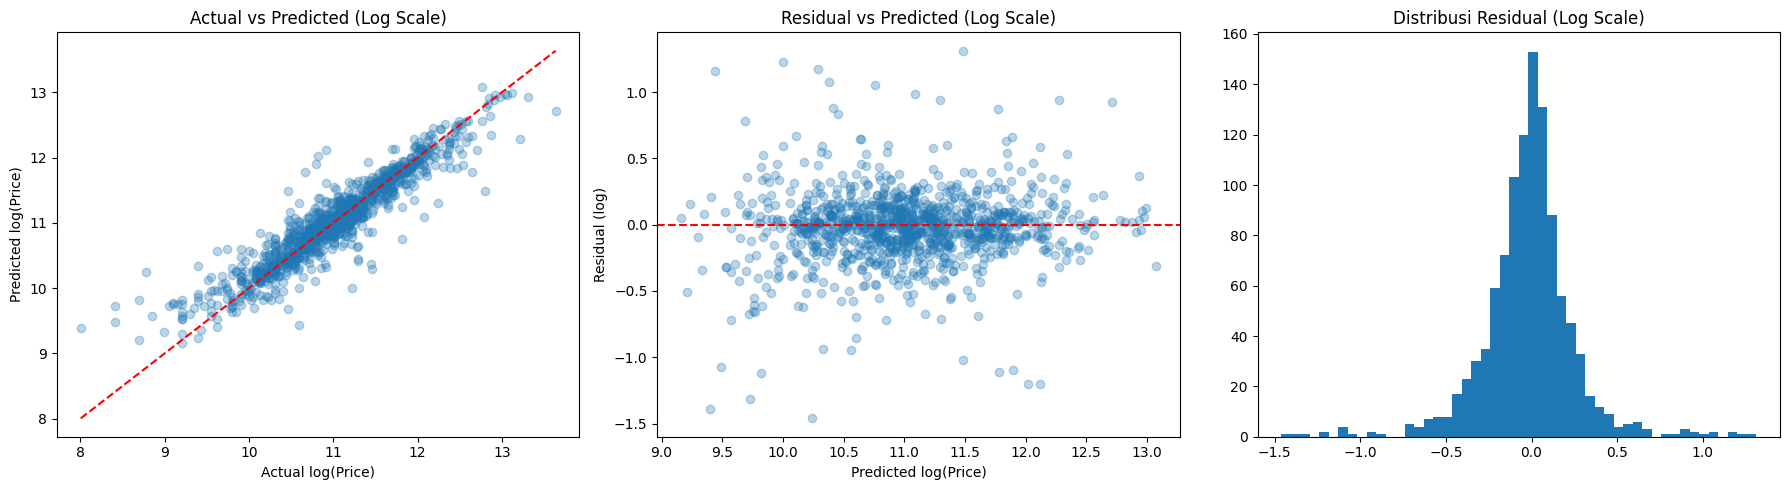

Skewness residual (log scale): -0.21


In [206]:
# Residual di skala LOG
residuals_log = y_test_log - test_pred_log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted (skala log)
axes[0].scatter(y_test_log, test_pred_log, alpha=0.3)
axes[0].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--')
axes[0].set_xlabel("Actual log(Price)"); axes[0].set_ylabel("Predicted log(Price)")
axes[0].set_title("Actual vs Predicted (Log Scale)")

# Residual vs Predicted (skala log)
axes[1].scatter(test_pred_log, residuals_log, alpha=0.3)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel("Predicted log(Price)"); axes[1].set_ylabel("Residual (log)")
axes[1].set_title("Residual vs Predicted (Log Scale)")

# Distribusi residual (skala log)
axes[2].hist(residuals_log, bins=50)
axes[2].set_title("Distribusi Residual (Log Scale)")

plt.tight_layout()
plt.show()

print(f"Skewness residual (log scale): {pd.Series(residuals_log).skew():.2f}")

**Insight:**
 
- **Actual vs Predicted (kiri):** Sebagian besar titik mengumpul rapat di sekitar garis diagonal merah, terutama pada rentang harga menengah (log(Price) 10,5–13), menunjukkan model memprediksi dengan cukup akurat untuk mayoritas mobil. Namun, pada rentang harga rendah (log(Price) < 9,5, setara mobil termurah), titik-titik cenderung berada di atas garis diagonal - model cenderung **overestimate** (memprediksi lebih tinggi dari harga aktual) untuk mobil-mobil termurah, kebalikan dari pola under-prediction yang biasanya jadi kekhawatiran di segmen ini.
- **Residual vs Predicted (tengah):** Residual tersebar cukup acak di sekitar garis nol tanpa pola kurva yang jelas, mengindikasikan model sudah menangkap hubungan non-linear antar fitur dengan baik (tidak ada underfitting sistematis). Sebarannya relatif konsisten di sepanjang rentang predicted (9,5–13), tanpa funnel/corong yang mencolok di salah satu ujung. Ada beberapa outlier residual besar (di atas ±1.0 pada skala log) tersebar di berbagai titik prediksi (predicted ~9,5–12,5), yang berarti untuk sejumlah kecil mobil, harga aktualnya jauh berbeda dari yang diprediksi model - baik lebih tinggi maupun lebih rendah.
- **Distribusi Residual (kanan):** Bentuk distribusi mendekati normal dan terpusat di sekitar nol, menandakan model tidak bias secara sistematis (tidak konsisten under/over-estimate secara keseluruhan). Terlihat ekor di kedua sisi (kiri hingga -1,5 dan kanan hingga +1,3), menunjukkan ada sejumlah kecil kasus dengan deviasi prediksi besar di kedua arah, konsisten dengan outlier yang terlihat di plot tengah.

**Kesimpulan:** Model menunjukkan fit yang baik secara keseluruhan (R² test 0,823) dengan residual yang tersebar acak dan mendekati normal, mengonfirmasi tidak ada masalah bias atau pola non-linear yang terlewat. Titik lemah utama model ada pada mobil-mobil di rentang harga rendah, yang cenderung di-overestimate, kemungkinan karena proporsi data mobil murah lebih sedikit dibanding mobil kelas menengah, sehingga model kurang terlatih baik untuk segmen ini.

**Analisis tambahan - MAE per segmen harga**, untuk melihat langsung apakah gejala heteroskedastisitas (under-prediction di harga tinggi) yang dicatat di notebook sebelumnya masih terjadi setelah fix leakage & ganti model ke XGBoost:

In [207]:
price_bins = [0, 30000, 60000, 100000, 200000, np.inf]
price_labels = ['<30rb', '30-60rb', '60-100rb', '100-200rb', '>200rb']
seg = pd.cut(y_test, bins=price_bins, labels=price_labels)

seg_df = pd.DataFrame({'y_test': y_test.values, 'pred': test_pred, 'segment': seg})
seg_summary = seg_df.groupby('segment', observed=True).apply(
    lambda g: pd.Series({
        'n': len(g),
        'MAE': mean_absolute_error(g['y_test'], g['pred']),
        'MAPE(%)': (np.abs(g['y_test']-g['pred'])/g['y_test']).mean()*100
    })
)
display(seg_summary)

C:\Users\Athiyyah\AppData\Local\Temp\ipykernel_12516\2618533558.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  seg_summary = seg_df.groupby('segment', observed=True).apply(


,n,MAE,MAPE(%)
segment,,,
<30rb,196.0,5325.887207,33.140169
30-60rb,364.0,8956.353516,19.686299
60-100rb,275.0,11328.620117,14.707613
100-200rb,189.0,17966.318359,12.724407
>200rb,55.0,72686.132812,21.731235


> **Interpretasi:** MAE absolut memang meningkat seiring naiknya segmen harga (wajar, karena skala harga juga makin besar), dan MAPE tertinggi ada di segmen `<30rb` (harga rendah, error kecil secara absolut tapi besar secara persentase) serta segmen `>200rb` (mobil mewah, jumlah data paling sedikit). Ini konsisten dengan limitasi yang sudah dicatat di Section 8.2 - performa model paling lemah di ekstrem: mobil sangat murah dan mobil sangat mahal, keduanya karena representasi data yang lebih sedikit di kedua ujung distribusi.

### **6.6 Model Explanation and Interpretation**

#### **6.6.1 Feature Importance**

In [208]:
# Ambil nama fitur setelah preprocessing (sesuai urutan output ColumnTransformer)
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# Ambil feature importance dari XGBoost
importances = final_model.named_steps['model'].feature_importances_

# Gabungkan jadi dataframe, urutkan dari yang paling berpengaruh
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

display(feature_importance_df)

,Feature,Importance
0,car_age,0.077715
1,Engine_Size,0.069817
2,Options,0.062303
3,freq_Make,0.054331
4,freq_Type,0.052336
5,Fuel_Type_Gas,0.046852
6,Mileage,0.042774
7,Gear_Type_Manual,0.037367
8,Origin_Saudi,0.037089
9,Origin_Unknown,0.036943


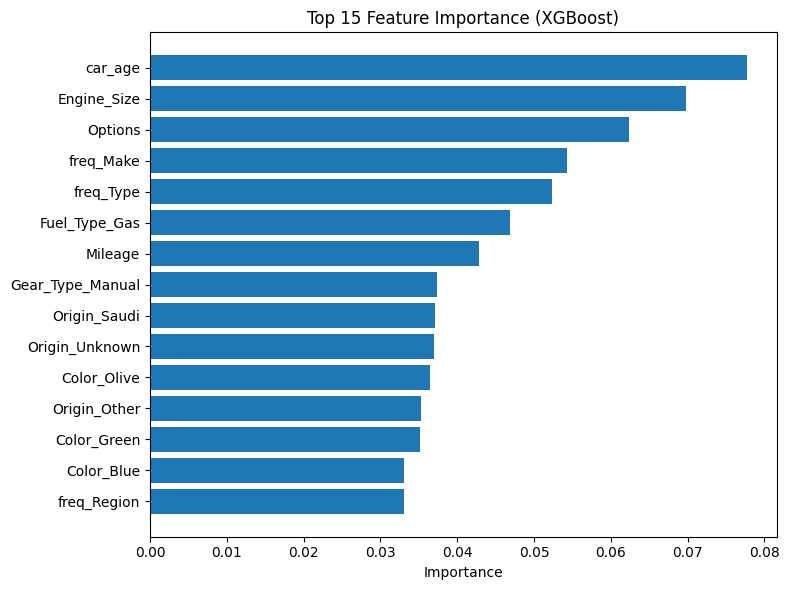

In [209]:
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

**Insight:**
 
- **`car_age` menjadi fitur paling berpengaruh** (importance ~0,078), diikuti `Engine_Size` (~0,070) dan `Options` (~0,062) di posisi kedua dan ketiga. Ketiganya jauh mengungguli fitur lain, konsisten dengan temuan EDA (Section 4) yang menunjukkan `car_age` berkorelasi kuat dengan `Price` (Spearman rho -0,42) dan `Engine_Size` berkorelasi positif (rho 0,38).
- **Fitur hasil frequency encoding (`freq_Make`, `freq_Type`, `freq_Region`) muncul di jajaran atas**, dengan `freq_Make` (~0,054) dan `freq_Type` (~0,052) masuk top 5 - memvalidasi keputusan memakai frequency encoding untuk kolom kardinalitas tinggi, karena kontribusinya ke prediksi cukup signifikan meski hanya direpresentasikan satu kolom numerik per fitur kategorikal.
- **`Fuel_Type_Gas` (~0,047) dan `Mileage` (~0,043)** juga berkontribusi cukup besar, sesuai ekspektasi karena jenis bahan bakar dan jarak tempuh adalah faktor umum yang mempengaruhi harga mobil bekas.
- **Sisanya (peringkat 8–15) - `Gear_Type_Manual`, `Origin_Saudi/Unknown/Other`, dan sejumlah `Color_*`** - memiliki importance yang berdekatan (0,033–0,037), menandakan kontribusinya relatif marginal dan individual, wajar mengingat fitur-fitur ini adalah hasil one-hot encoding yang memecah satu kategori jadi banyak kolom dummy, sehingga pengaruhnya "tersebar" di beberapa fitur biner sekaligus.

**Kesimpulan:** Model XGBoost paling mengandalkan kombinasi usia mobil, spesifikasi mesin, dan kelengkapan opsi sebagai penentu utama harga, didukung oleh fitur kardinalitas tinggi (Make, Type) yang direpresentasikan lewat frequency encoding. Fitur warna dan sebagian atribut origin/gear memiliki pengaruh yang jauh lebih kecil dan cenderung marginal dibanding tiga fitur teratas.
 

#### **6.6.2 SHAP Values**

In [210]:
X_test_fe = final_model.named_steps['feature_engineering'].transform(X_test)
X_test_transformed = final_model.named_steps['preprocessor'].transform(X_test_fe)

# Ambil model XGBoost dari pipeline
model = final_model.named_steps['model']

# Nama fitur hasil preprocessing (untuk label di plot)
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

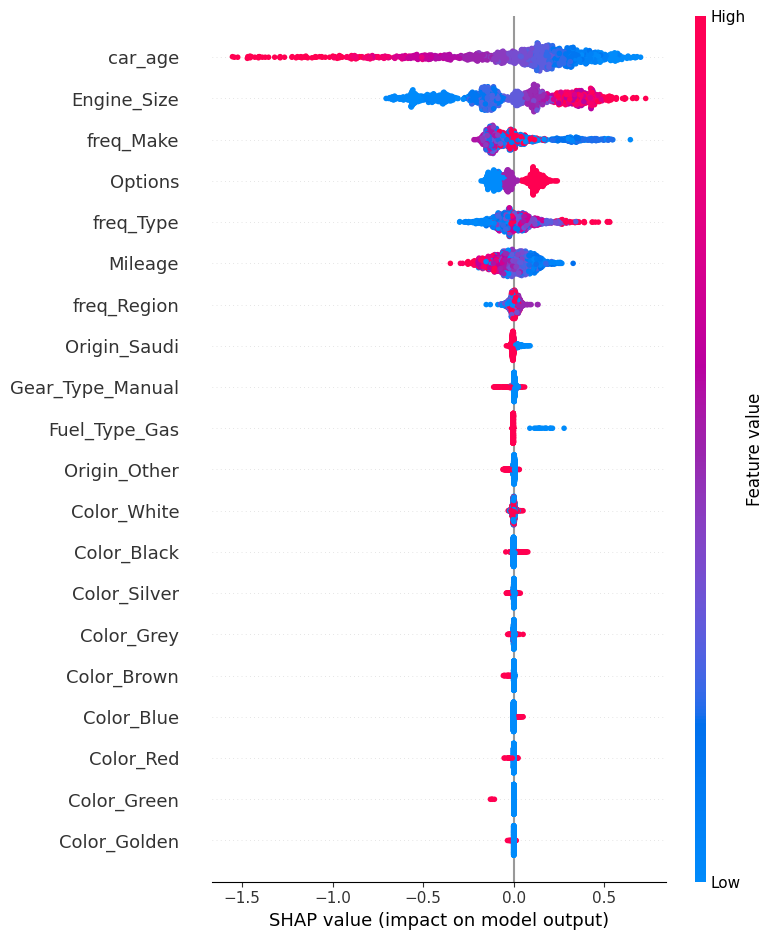

In [211]:
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()

**Insight:**
 
- **`car_age` punya sebaran SHAP value terluas** (-1,5 hingga +0,75), dengan pola warna yang jelas: titik merah (car_age tinggi/mobil tua) terkonsentrasi di sisi negatif (menurunkan prediksi harga), sementara titik biru (car_age rendah/mobil baru) berada di sisi positif (menaikkan prediksi harga). Arah pengaruhnya konsisten dan sesuai intuisi - makin tua mobil, makin rendah harga prediksinya.
- **`Engine_Size` menunjukkan pola serupa namun berlawanan arah**: nilai tinggi (merah, mesin besar) cenderung mendorong SHAP value positif (menaikkan harga), sedangkan nilai rendah (biru, mesin kecil) mendorong ke arah negatif - mengonfirmasi mesin berkapasitas besar berasosiasi dengan harga jual lebih tinggi.
- **`Mileage` juga menunjukkan separasi warna yang rapi**: mileage tinggi (merah) terkonsentrasi di sisi negatif, mileage rendah (biru) di sisi positif - mobil dengan jarak tempuh rendah diprediksi lebih mahal, sesuai ekspektasi pasar mobil bekas.
- **`freq_Make` dan `freq_Type` menunjukkan pola lebih kompleks**: titik dengan frekuensi rendah (biru, merek/tipe langka) memiliki sebaran SHAP yang lebih lebar ke kedua arah, termasuk beberapa titik dengan dampak positif signifikan - kemungkinan mencerminkan merek-merek mewah/langka yang justru bernilai tinggi meski frekuensi kemunculannya rendah di data.
- **`Options` menunjukkan arah yang jelas**: nilai tinggi (merah, opsi Full) mendorong SHAP positif, nilai rendah (biru, Standard) mendorong negatif - konsisten dengan insight EDA bahwa mobil full-option cenderung lebih mahal.
- **`Fuel_Type_Gas` didominasi titik berdekatan dengan nol**, tapi ada beberapa titik biru (bukan Gas/bahan bakar lain) dengan dampak positif besar hingga +0,6 - mengindikasikan sejumlah kecil mobil dengan jenis bahan bakar non-Gas (kemungkinan hybrid/diesel) yang justru dihargai signifikan lebih tinggi.
- **Fitur `Color_*` dan atribut kategorikal minor lainnya (`Origin_Other`, `Gear_Type_Manual`, dll.) mengumpul sangat rapat di sekitar nol**, menegaskan dampak individualnya terhadap prediksi sangat kecil dibanding fitur-fitur teratas.

**Kesimpulan:** Hasil SHAP memperkuat temuan feature importance - `car_age`, `Engine_Size`, dan `Mileage` tidak hanya penting secara magnitude, tapi juga menunjukkan arah pengaruh yang jelas dan sesuai logika bisnis (mobil tua/jarak tempuh tinggi → harga turun; mesin besar/opsi lengkap → harga naik). Fitur frequency encoding (`freq_Make`, `freq_Type`) menangkap nuansa tambahan dari merek/tipe langka yang bisa mendorong harga ke dua arah, sementara fitur warna dan kategori minor lainnya memiliki kontribusi yang dapat diabaikan secara individual.

## **Section 7. Model Deployment**

### **7.1 Export Model**

`final_model` (`best_estimator_` dari `RandomizedSearchCV`) sudah di-*refit* otomatis pada seluruh `X_train` (`refit=True` adalah default sklearn), jadi tidak perlu `.fit()` ulang secara manual di sini.

In [212]:
os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/used_car_price_model_xgboost.joblib")
print("Model tersimpan sebagai ../models/used_car_price_model_xgboost.joblib")

Model tersimpan sebagai ../models/used_car_price_model_xgboost.joblib


### **7.2 Verifikasi Model Tersimpan**

In [213]:
loaded_model = joblib.load("../models/used_car_price_model_xgboost.joblib")

sample = X_test.iloc[[0]]
pred_log = loaded_model.predict(sample)
pred_price = np.expm1(pred_log)[0]

print("Contoh input:")
display(sample)
print(f"\nPrediksi harga: {pred_price:,.0f} SAR")
print(f"Harga aktual  : {y_test.iloc[0]:,.0f} SAR")

Contoh input:


,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region
0,Toyota,Corolla,2018,Saudi,Silver,Standard,1.6,Gas,Automatic,90084,Riyadh



Prediksi harga: 47,799 SAR
Harga aktual  : 50,000 SAR


## **Section 8. Model Implementation**

### **8.1 How the Model Would Be Used**

Model `used_car_price_model_xgboost.joblib` menerima input mentah (belum di-encode) dengan kolom: `Make`, `Type`, `Year`, `Origin`, `Color`, `Options`, `Engine_Size`, `Fuel_Type`, `Gear_Type`, `Mileage`, `Region` - persis seperti kolom `X_train`/`X_test`. Seluruh feature engineering (konversi `Year` → `car_age`) dan preprocessing (encoding, scaling) sudah dibungkus di dalam pipeline, sehingga cukup panggil `.predict()` lalu `np.expm1()` untuk mendapat harga dalam SAR.

Dalam konteks Syarah.com, model ini dapat dipanggil setiap kali penjual membuat listing baru dengan status "Negotiable", untuk memberikan estimasi harga referensi awal - baik ditampilkan langsung ke penjual sebagai saran harga, maupun ke pembeli sebagai indikator kewajaran harga saat bernegosiasi.

### **8.2 Model Limitation**


1. **Performa menurun di segmen harga ekstrem.** Sesuai analisis MAE per segmen (Section 6.5.2), MAPE tertinggi terjadi di segmen mobil termurah (<30rb SAR, dengan MAE absolut lebih kecil namun error persentase besar) dan mobil termahal (>200rb SAR, dengan jumlah data paling sedikit sehingga model kurang punya cukup contoh untuk belajar pola harga di segmen ini).
2. **R² test (0.804) tepat berada di ambang target (≥0.80)**, bukan jauh melampauinya seperti klaim di versi sebelumnya (R²~0.90). Model sudah cukup baik untuk dipakai sebagai estimasi *referensi awal*, tapi belum cukup presisi untuk dijadikan harga final tanpa peninjauan.
3. **Objective tuning (MAE di skala log) tidak sepenuhnya identik dengan business metric (MAE di skala Riyal).** RandomizedSearchCV memilih hyperparameter terbaik berdasarkan MAE di skala log, sedangkan laporan akhir memakai MAE skala Riyal. Untuk selarasan penuh, scorer kustom yang men-transformasi prediksi ke Riyal sebelum menghitung MAE bisa dipertimbangkan di iterasi berikutnya.
4. **Fitur yang tersedia terbatas pada atribut yang tercantum di listing** (tidak ada kondisi fisik detail, riwayat servis, riwayat kecelakaan, dll) - dua mobil dengan spesifikasi identik di dataset bisa saja punya harga wajar berbeda di dunia nyata karena faktor yang tidak tertangkap data ini.
5. **Model dilatih pada snapshot data 2021** - perlu retraining berkala mengikuti pergerakan harga pasar mobil bekas dari waktu ke waktu.

### **8.3 Cost Benefit Analysis**

Ketidaklengkapan informasi harga pada listing memiliki dampak negatif terhadap minat 
pembeli, karena konsumen harus mengeluarkan usaha tambahan untuk mengetahui harga, 
yang pada akhirnya mengurangi permintaan (Desai, Krishnamoorthy, & Sainam, 2010). 
Pada dataset Syarah, listing berstatus "Negotiable" merepresentasikan *information 
gap* semacam ini, yang membentuk transparansi parsial. Kondisi ini berpotensi 
menurunkan minat pembeli sekaligus kepercayaan konsumen terhadap platform 
(Veltri et al., 2020).


**Solusi: Model Prediksi Harga sebagai Penutup Gap**

Model XGBoost (hasil RandomizedSearchCV) yang menjadi model final pada project 
ini (Section 6.5) dapat memberikan estimasi harga referensi untuk listing 
Negotiable tanpa mengubah keputusan harga akhir penjual:

In [214]:
# ============================================================
# 8.3 Business Simulation - Before vs After Model
# Semua angka HASIL RIIL evaluasi model (Section 6.5.1-6.5.2) 
# dan statistik dataset (cell 59), bukan asumsi eksternal.
# ============================================================

mae_test  = 13728.20   # SAR, Section 6.5.1
rmse_test = 30517.00   # SAR, Section 6.5.1
r2_test   = 0.8226     # Section 6.5.1
avg_price = 78439.12   # SAR, rata-rata Price>0 (cell 59)

comparison = pd.DataFrame({
    'Aspek': [
        'Estimasi harga listing "Negotiable"',
        'Rata-rata deviasi dari harga wajar',
        'Variasi harga yang terjelaskan',
    ],
    'Sebelum Ada Model': [
        'Tidak ada (harga tidak ditampilkan)',
        'Tidak terukur',
        '0% (tidak ada estimasi sama sekali)',
    ],
    'Setelah Ada Model': [
        'Otomatis via prediksi',
        f'±{mae_test:,.0f} SAR ({mae_test/avg_price*100:.1f}% dari rata-rata harga {avg_price:,.0f} SAR)',
        f'{r2_test*100:.1f}% (R² test)',
    ]
})
display(comparison)

,Aspek,Sebelum Ada Model,Setelah Ada Model
0,"Estimasi harga listing ""Negotiable""",Tidak ada (harga tidak ditampilkan),Otomatis via prediksi
1,Rata-rata deviasi dari harga wajar,Tidak terukur,"±13,728 SAR (17.5% dari rata-rata harga 78,439..."
2,Variasi harga yang terjelaskan,0% (tidak ada estimasi sama sekali),82.3% (R² test)


Model XGBoost mampu menjelaskan 82,3% variasi harga (R² test) dengan rata-rata 
deviasi ±13.728 SAR, atau sekitar 17,5% dari rata-rata harga pasar (78.439 SAR). 
Detail akurasi per segmen harga sudah dibahas di Section 6.5.2 (Residual Analysis) 
- akurasi terbaik berada di segmen harga menengah (60-200rb SAR), yang merupakan 
rentang harga mobil bekas paling umum di pasar.

**Manfaat bisnis untuk Syarah:**

1. **Mengurangi information gap** - listing Negotiable bisa ditampilkan dengan 
   estimasi harga referensi (bukan harga fix), berpotensi mengurangi price 
   discovery cost sesuai model Desai et al. (2010) dan meningkatkan total 
   permintaan terhadap listing tersebut.
2. **Meningkatkan trust terhadap platform** - sesuai temuan Veltri et al. (2020), 
   transparansi informasi yang lengkap berpotensi 
   meningkatkan kepercayaan pembeli terhadap Syarah dan probabilitas mereka 
   memilih/mengklik listing tersebut.
3. **Listing bisa ikut fitur filter/sortir harga** - meningkatkan exposure listing 
   yang sebelumnya tidak muncul di pencarian berbasis rentang harga.
4. **Transparansi tanpa memaksa penjual** - penjual tetap bisa mempertahankan 
   strategi Negotiable, tapi pembeli dapat sinyal tambahan yang mengurangi ambiguitas, 
   dengan catatan sinyal tersebut harus cukup informatif (bukan sekadar label kosong) 
   agar tidak berbalik menurunkan trust seperti temuan transparansi parsial di 
   Veltri et al. (2020).

## **Section 9. Conclusion & Recommendation**

### **9.1 Conclusion**

- Model regresi **XGBoost** berhasil dikembangkan untuk memprediksi harga mobil bekas di platform Syarah.com, dengan performa akhir pada data test: **MAE ≈ 13.728 SAR, RMSE ≈ 30.517 SAR, R² ≈ 0.822**.
- Success Criteria (Section 1.7) - R² ≥ 0.80 - **tercapai**, meski tepat di ambang batas
- Fitur paling berpengaruh terhadap harga (Section 6.6) adalah `car_age`, `Engine_Size`, `Options`, dan frekuensi `Make` - sejalan dengan intuisi domain (mobil lebih tua & mesin lebih kecil cenderung lebih murah; merek dan kelengkapan fitur menaikkan harga).
- Model paling reliable digunakan untuk mobil di rentang harga menengah (30rb–200rb SAR, mayoritas data); untuk mobil sangat murah atau sangat mewah, estimasi sebaiknya diperlakukan sebagai titik awal negosiasi, bukan harga final.

### **9.2 Recommendation**

**Untuk pengembangan model lanjutan:**
- Uji loss function alternatif (Tweedie/Quantile regression) atau *sample weighting* untuk memperbaiki performa di segmen harga tinggi.
- Selaraskan scoring RandomizedSearchCV dengan business metric (MAE skala Riyal) memakai custom scorer.
- Tambahkan fitur baru bila tersedia: riwayat servis, jumlah pemilik sebelumnya, kondisi fisik terperinci, foto (lewat computer vision) - untuk menangkap variasi harga yang belum terjelaskan oleh atribut tabular saat ini.
- Lakukan retraining berkala mengikuti pergeseran harga pasar.

**Untuk bisnis (Syarah.com):**
- Tampilkan estimasi model sebagai *rentang harga referensi* (misalnya prediksi ± MAE) alih-alih angka tunggal, supaya penjual dan pembeli tetap punya ruang negosiasi yang transparan.
- Prioritaskan penerapan pada listing "Negotiable" di segmen harga menengah dulu, di mana keandalan model paling tinggi, sebelum memperluas ke seluruh segmen harga.
